# Importing the Libraries

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
import torch
from IPython.display import Image
import shutil
import os
from random import choice

# Cloning YoloV5 git Repo

In [5]:
!git clone https://github.com/ultralytics/yolov5 #https://github.com/ultralytics/yolov5

Cloning into 'yolov5'...
remote: Enumerating objects: 16008, done.
remote: Counting objects: 100% (41/41), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 16008 (delta 22), reused 22 (delta 13), pack-reused 15967
Receiving objects: 100% (16008/16008), 14.66 MiB | 20.12 MiB/s, done.
Resolving deltas: 100% (10984/10984), done.


In [6]:
%cd /content/yolov5/

/content/yolov5


# Installing YoloV5 requirements files

In [7]:
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.0/190.0 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.5/644.5 kB 23.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 8.5 MB/s eta 0:00:00


In [8]:
# arrays to store file names
imgs = []
xmls = []

# setup directory names
train_path = "/content/drive/MyDrive/12/data/train/images"
val_path = "/content/drive/MyDrive/12/data/valid/images"
crs_path = "/content/drive/MyDrive/12/data/images"

train_ratio = 0.8
val_ratio = 0.2

# total count of imgs
total_img_count = len(os.listdir(crs_path))/2

# sorting count of imgs
for (dirname,dirs, files) in os.walk(crs_path):
#     print(files)
    for filename in files:
#         print("hello")
        if filename.endswith(".txt"):
            xmls.append(filename)
        else:
            imgs.append(filename)

# counting range for cycles
count_for_train = int(len(imgs)*train_ratio)
count_for_val = int(len(imgs)*val_ratio)
print("training images are : ",count_for_train)
print("validation images are : ",count_for_val)

training images are :  111
validation images are :  27


In [9]:
len(imgs)

139

In [10]:
train_image_path = "/content/drive/MyDrive/12/data/train/images"
train_label_path = "/content/drive/MyDrive/12/data/train/labels"
val_image_path = "/content/drive/MyDrive/12/data/valid/images"
val_label_path = "/content/drive/MyDrive/12/data/valid/labels"

if not os.path.isdir(train_image_path):
    os.makedirs(train_image_path)
if not os.path.isdir(train_label_path):
    os.makedirs(train_label_path)
if not os.path.isdir(val_image_path):
    os.makedirs(val_image_path)
if not os.path.isdir(val_label_path):
    os.makedirs(val_label_path)

# cycle for train dir
for x in range(count_for_train):
    file_jpg = choice(imgs)
    file_xml = file_jpg[:-4] + ".txt"

    shutil.copy(os.path.join(crs_path,file_jpg),os.path.join(train_image_path,file_jpg))
    shutil.copy(os.path.join(crs_path,file_xml),os.path.join(train_label_path,file_xml))

    imgs.remove(file_jpg)
    xmls.remove(file_xml)

# cycle for test dir
for x in range(count_for_val):
    file_jpg = choice(imgs)
    file_xml = file_jpg[:-4] + ".txt"

    shutil.copy(os.path.join(crs_path,file_jpg),os.path.join(val_image_path,file_jpg))
    shutil.copy(os.path.join(crs_path,file_xml),os.path.join(val_label_path,file_xml))

    imgs.remove(file_jpg)
    xmls.remove(file_xml)

# rest of files
print("images length - ",len(imgs))
print(imgs,xmls)
for x in imgs:
    file_jpg = x
    file_xml = file_jpg[:-4] + ".txt"

    shutil.copy(os.path.join(crs_path,file_jpg),os.path.join(val_image_path,file_jpg))
    shutil.copy(os.path.join(crs_path,file_xml),os.path.join(val_label_path,file_xml))
# shutil.copytree(crs_path,val_path)

images length -  1
['04_spur_14_jpg.rf.69fdde66bd61577e693d2604c50f1ce3.jpg'] ['04_spur_14_jpg.rf.69fdde66bd61577e693d2604c50f1ce3.txt']


In [4]:
ML_Model = []
precision = []
recall = []
mAP = []

#function to call for storing the results
def storeResults(model, a,b,c):
    ML_Model.append(model)
    precision.append(round(a, 3))
    recall.append(round(b, 3))
    mAP.append(round(c, 3))

# Downloading dataset.yaml file from google cloud for the dataset

In [11]:
with open(r'/content/drive/MyDrive/12/data/data.yaml', 'r') as file:
    lines = file.readlines()
    print(lines)

['train: /content/drive/MyDrive/12/data/train/images\n', 'val: /content/drive/MyDrive/12/data/valid/images\n', '\n', '\n', 'nc: 6\n', "names: ['missing_hole', 'mouse_bite', 'open_circuit', 'short', 'spur', 'spurious_copper']\n", '\n', 'roboflow:\n', '  workspace: tru-projects-7dbwp\n', '  project: pcb-defect-detection-pizr5\n', '  version: 1\n', '  license: CC BY 4.0\n', '  url: https://universe.roboflow.com/tru-projects-7dbwp/pcb-defect-detection-pizr5/dataset/1']


YoloV5s- small


In [12]:
!wandb disabled
!python train.py --img 416 --batch 16 --epochs 500 --data /content/drive/MyDrive/12/data/data.yaml --weights yolov5s.pt --cache --workers 2

/bin/bash: line 1: wandb: command not found
train: weights=yolov5s.pt, cfg=, data=/content/drive/MyDrive/12/data/data.yaml, hyp=data/hyps/hyp.scratch-low.yaml, epochs=500, batch_size=16, imgsz=416, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, bucket=, cache=ram, image_weights=False, device=, multi_scale=False, single_cls=False, optimizer=SGD, sync_bn=False, workers=2, project=runs/train, name=exp, exist_ok=False, quad=False, cos_lr=False, label_smoothing=0.0, patience=100, freeze=[0], save_period=-1, seed=0, local_rank=-1, entity=None, upload_dataset=False, bbox_interval=-1, artifact_alias=latest
github: up to date with https://github.com/ultralytics/yolov5 ✅
YOLOv5 🚀 v7.0-227-ge4df1ec Python-3.10.12 torch-2.0.1+cu118 CUDA:0 (Tesla T4, 15102MiB)

hyperparameters: lr0=0.01, lrf=0.01, momentum=0.937, weight_decay=0.0005, warmup_epochs=3.0, warmup_momentum=0.8, warmup_bias_lr=0.1, box=0.05, cls=0.5, cls_pw=1.0, obj=1.0, obj_pw=1.0, i

In [5]:
p_yol5 = 0.803
r_yol5 = 0.816
mAP_yolo5 = 0.779

storeResults('YoloV5s',p_yol5,r_yol5,mAP_yolo5)

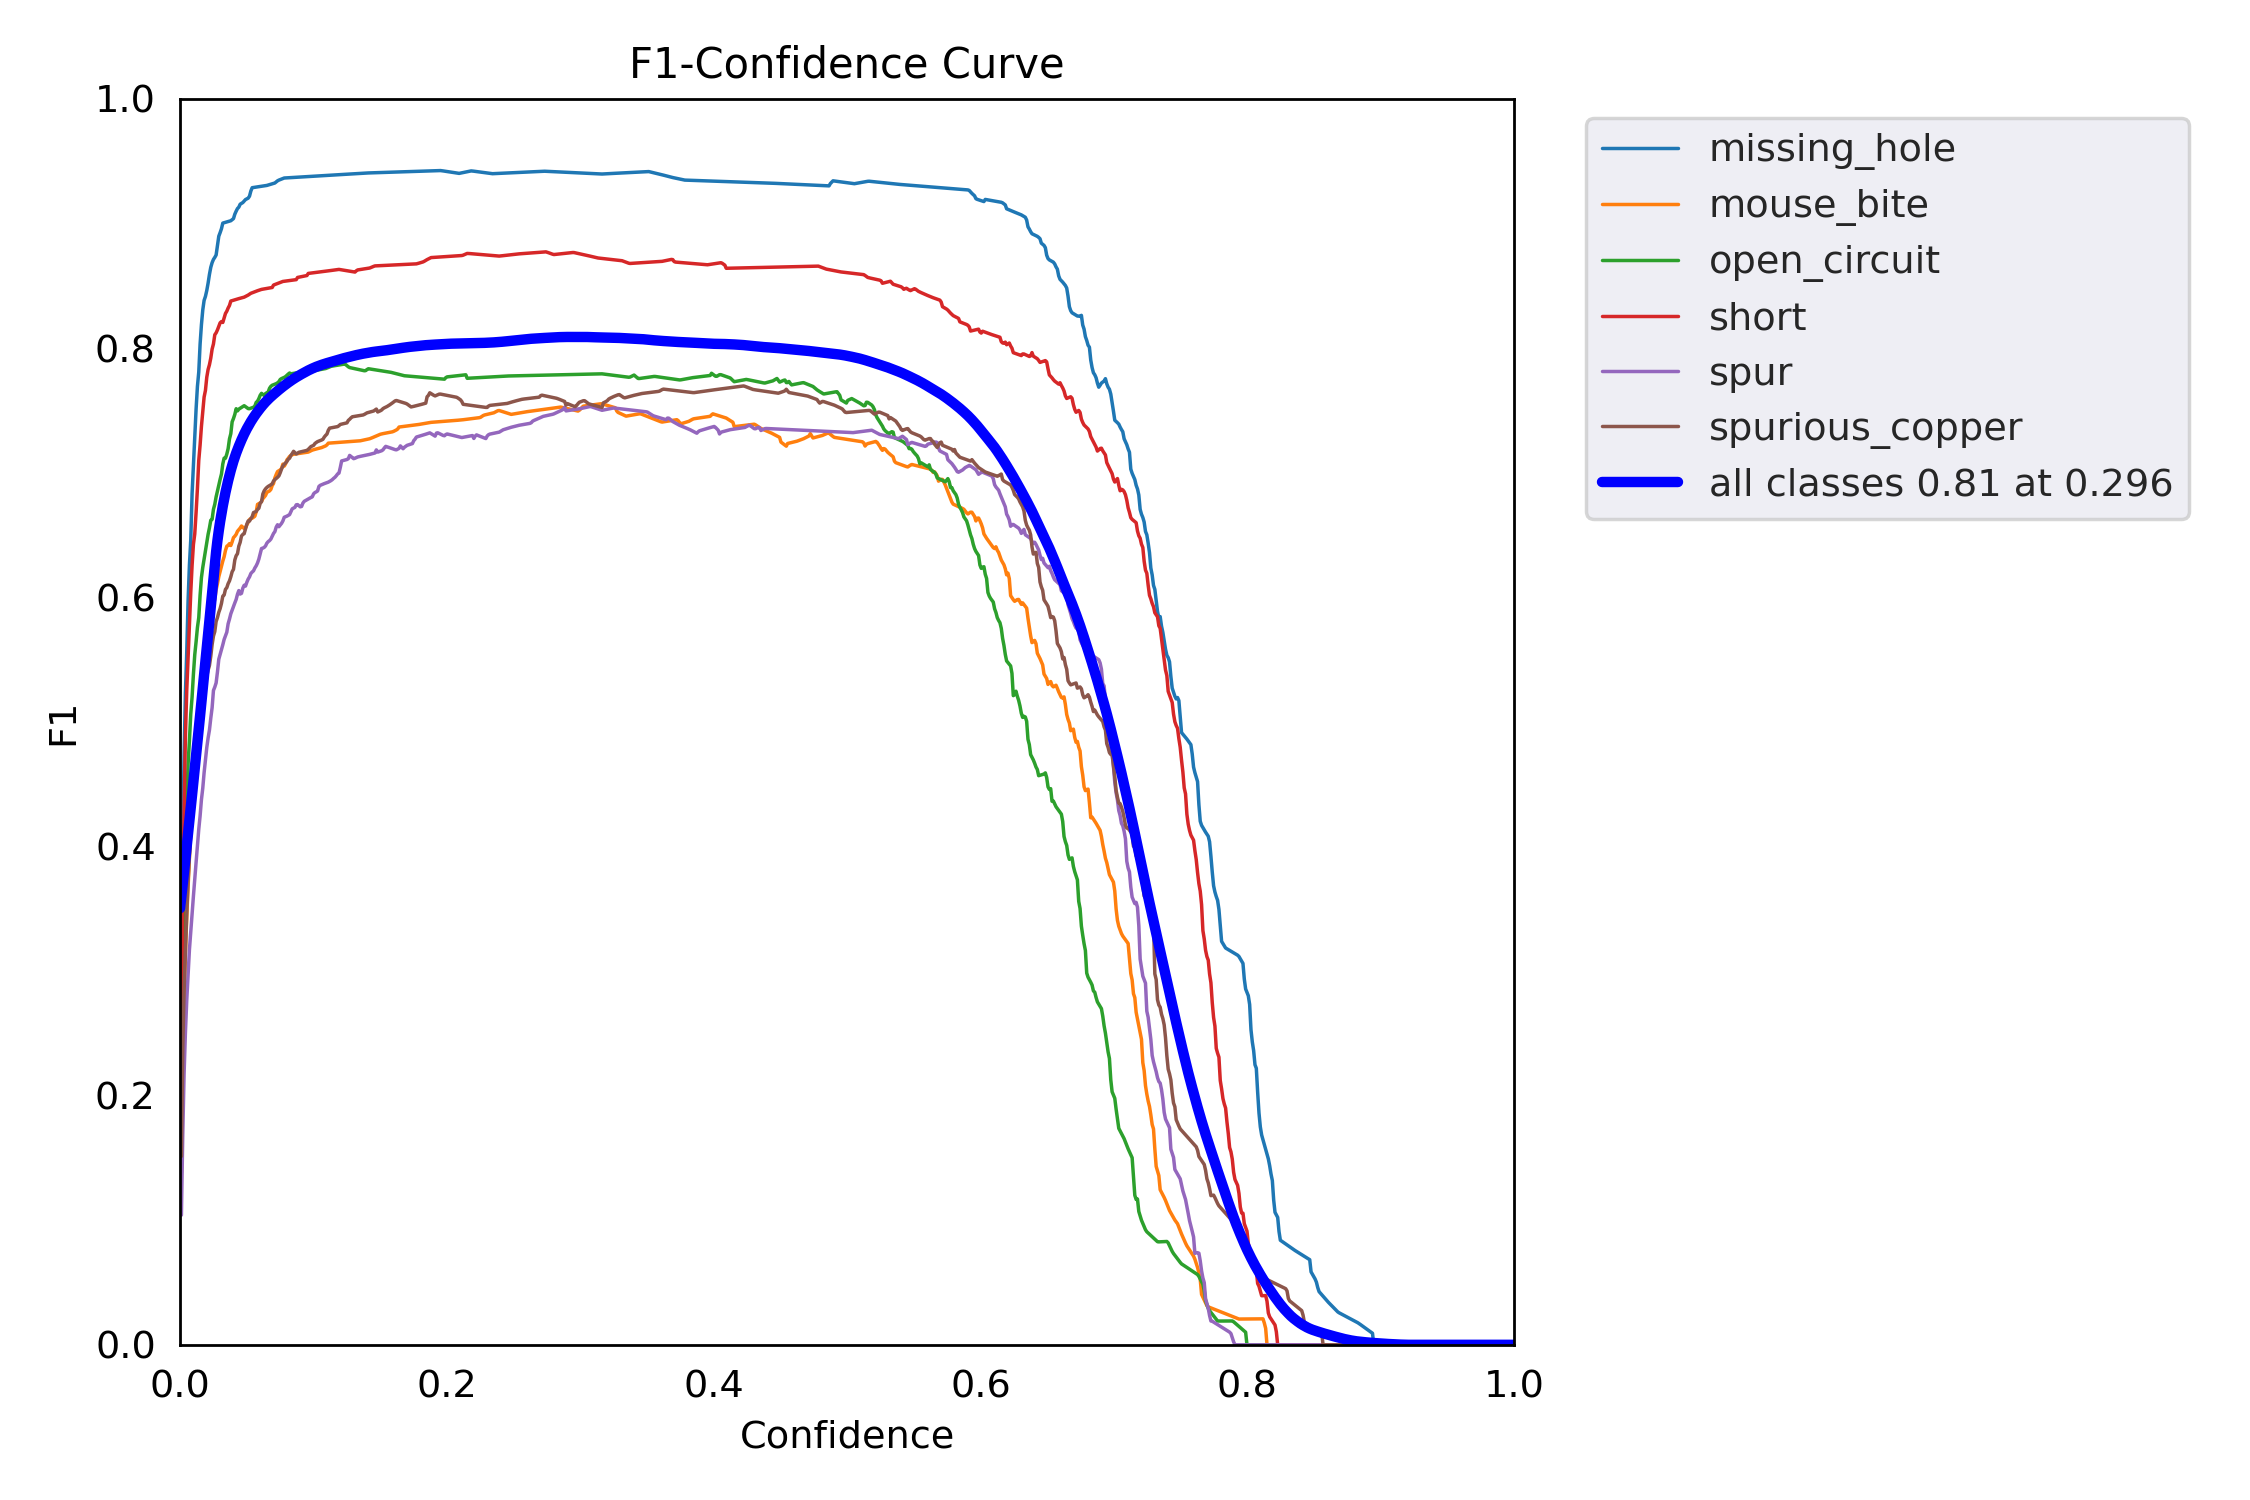

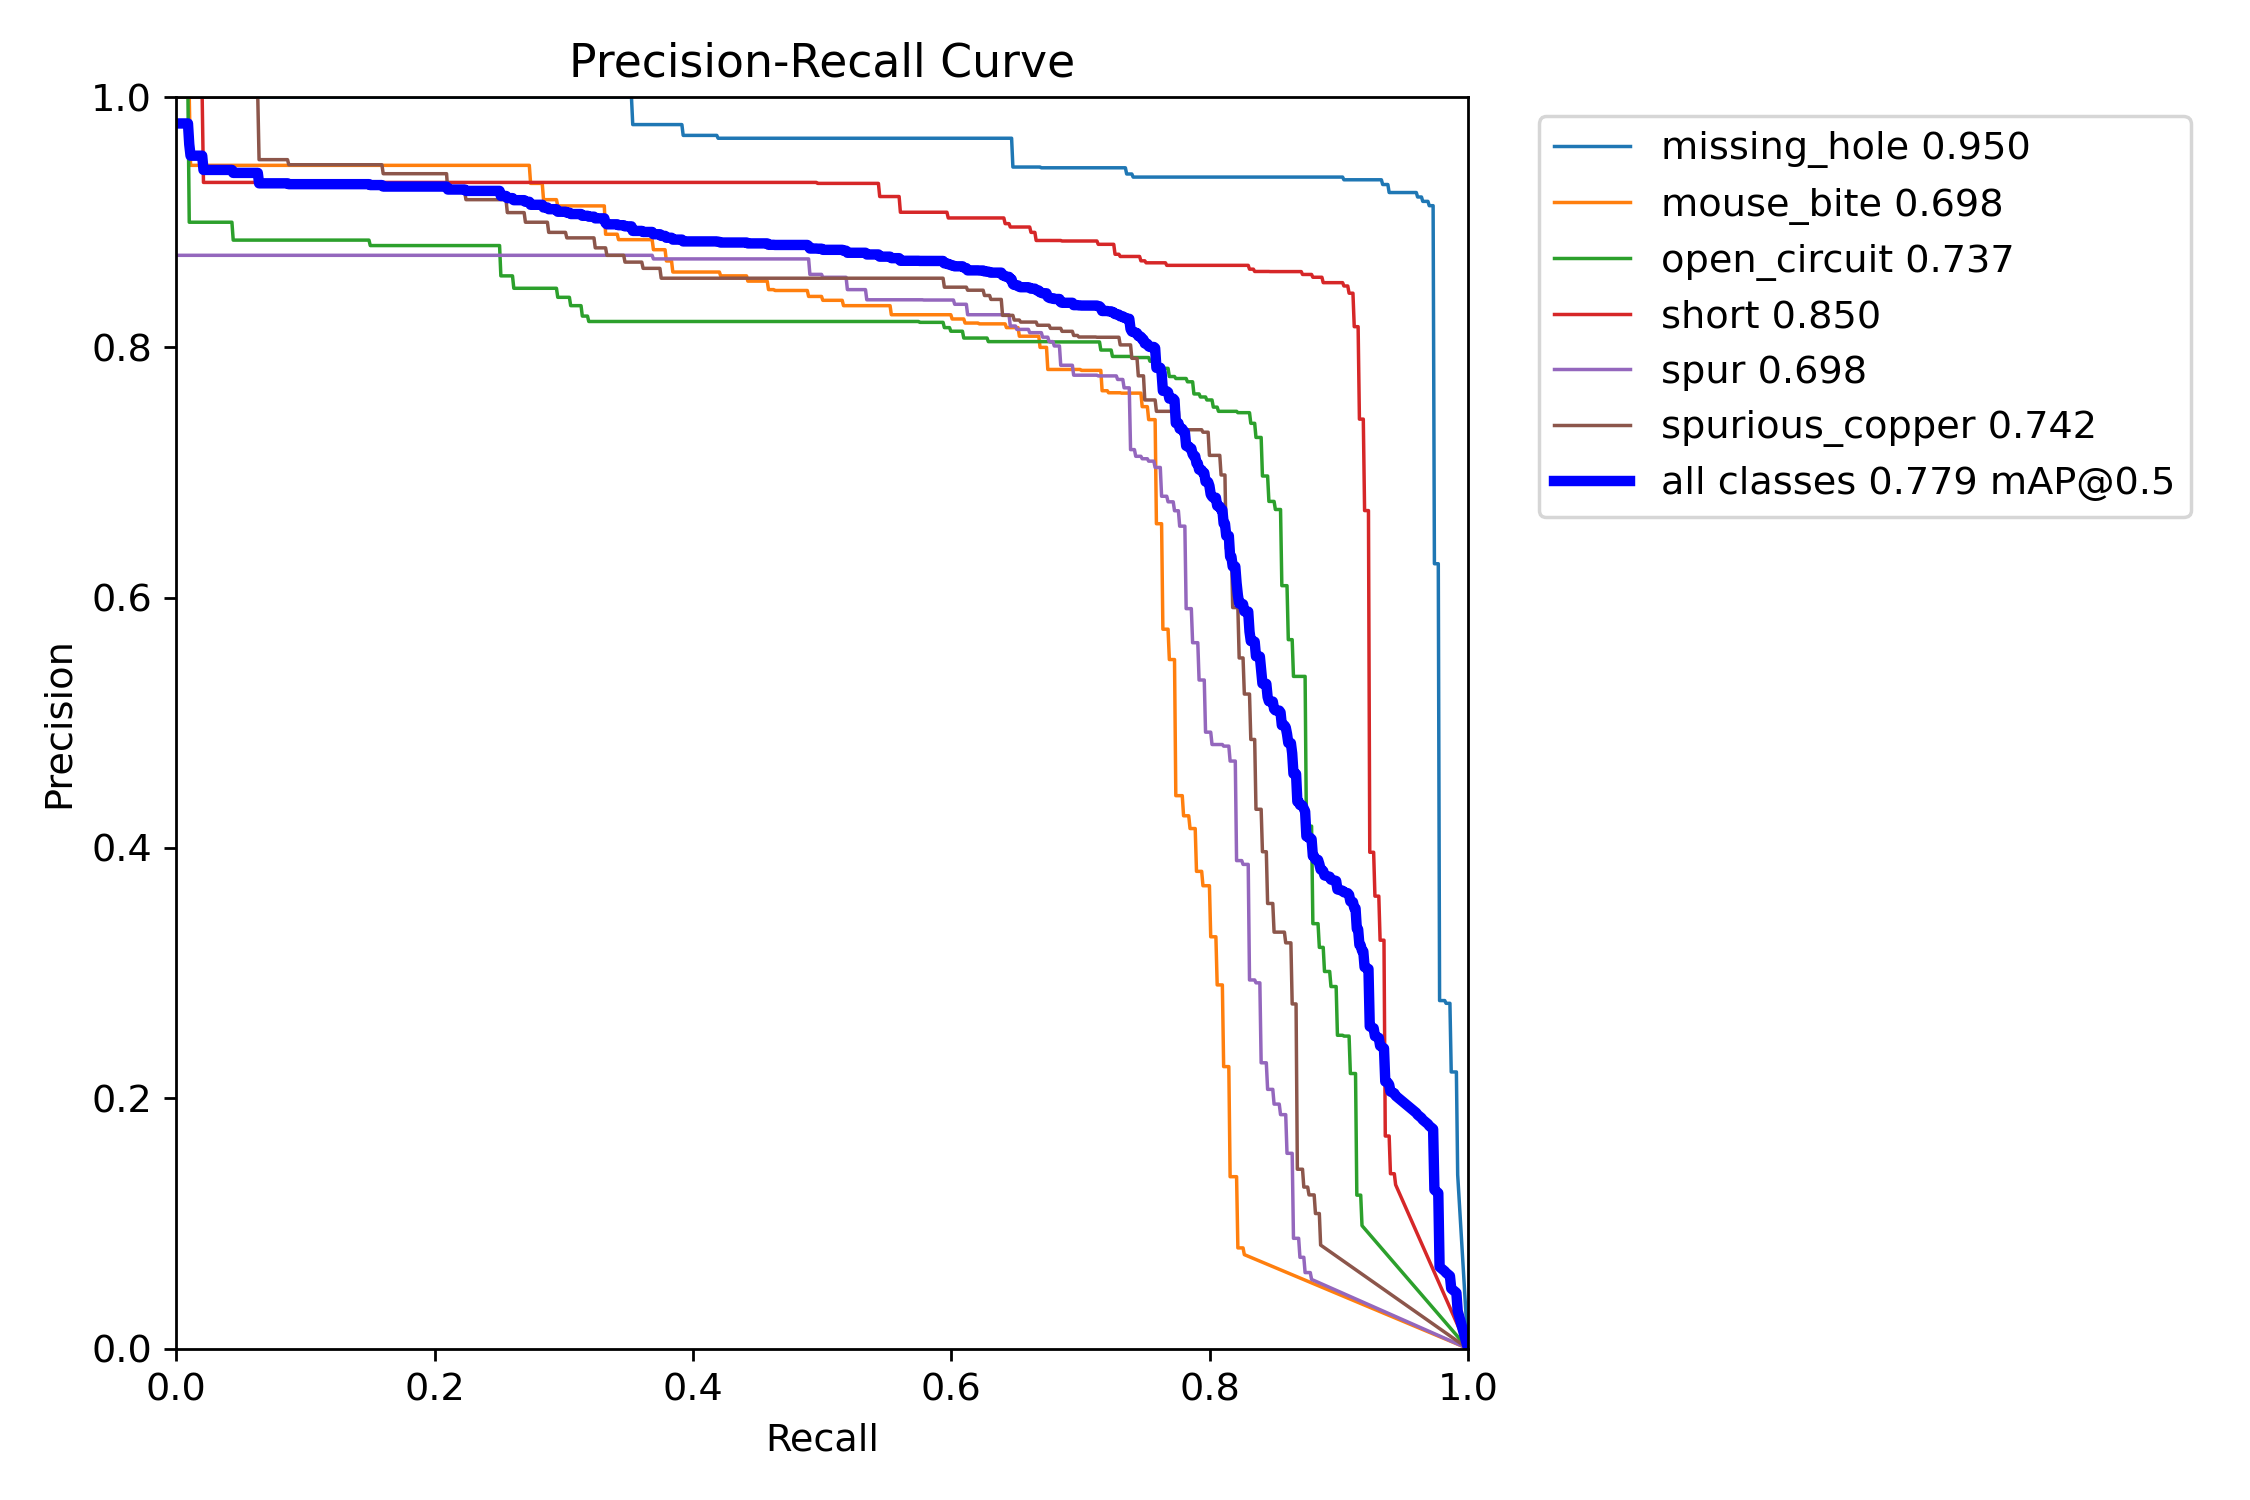

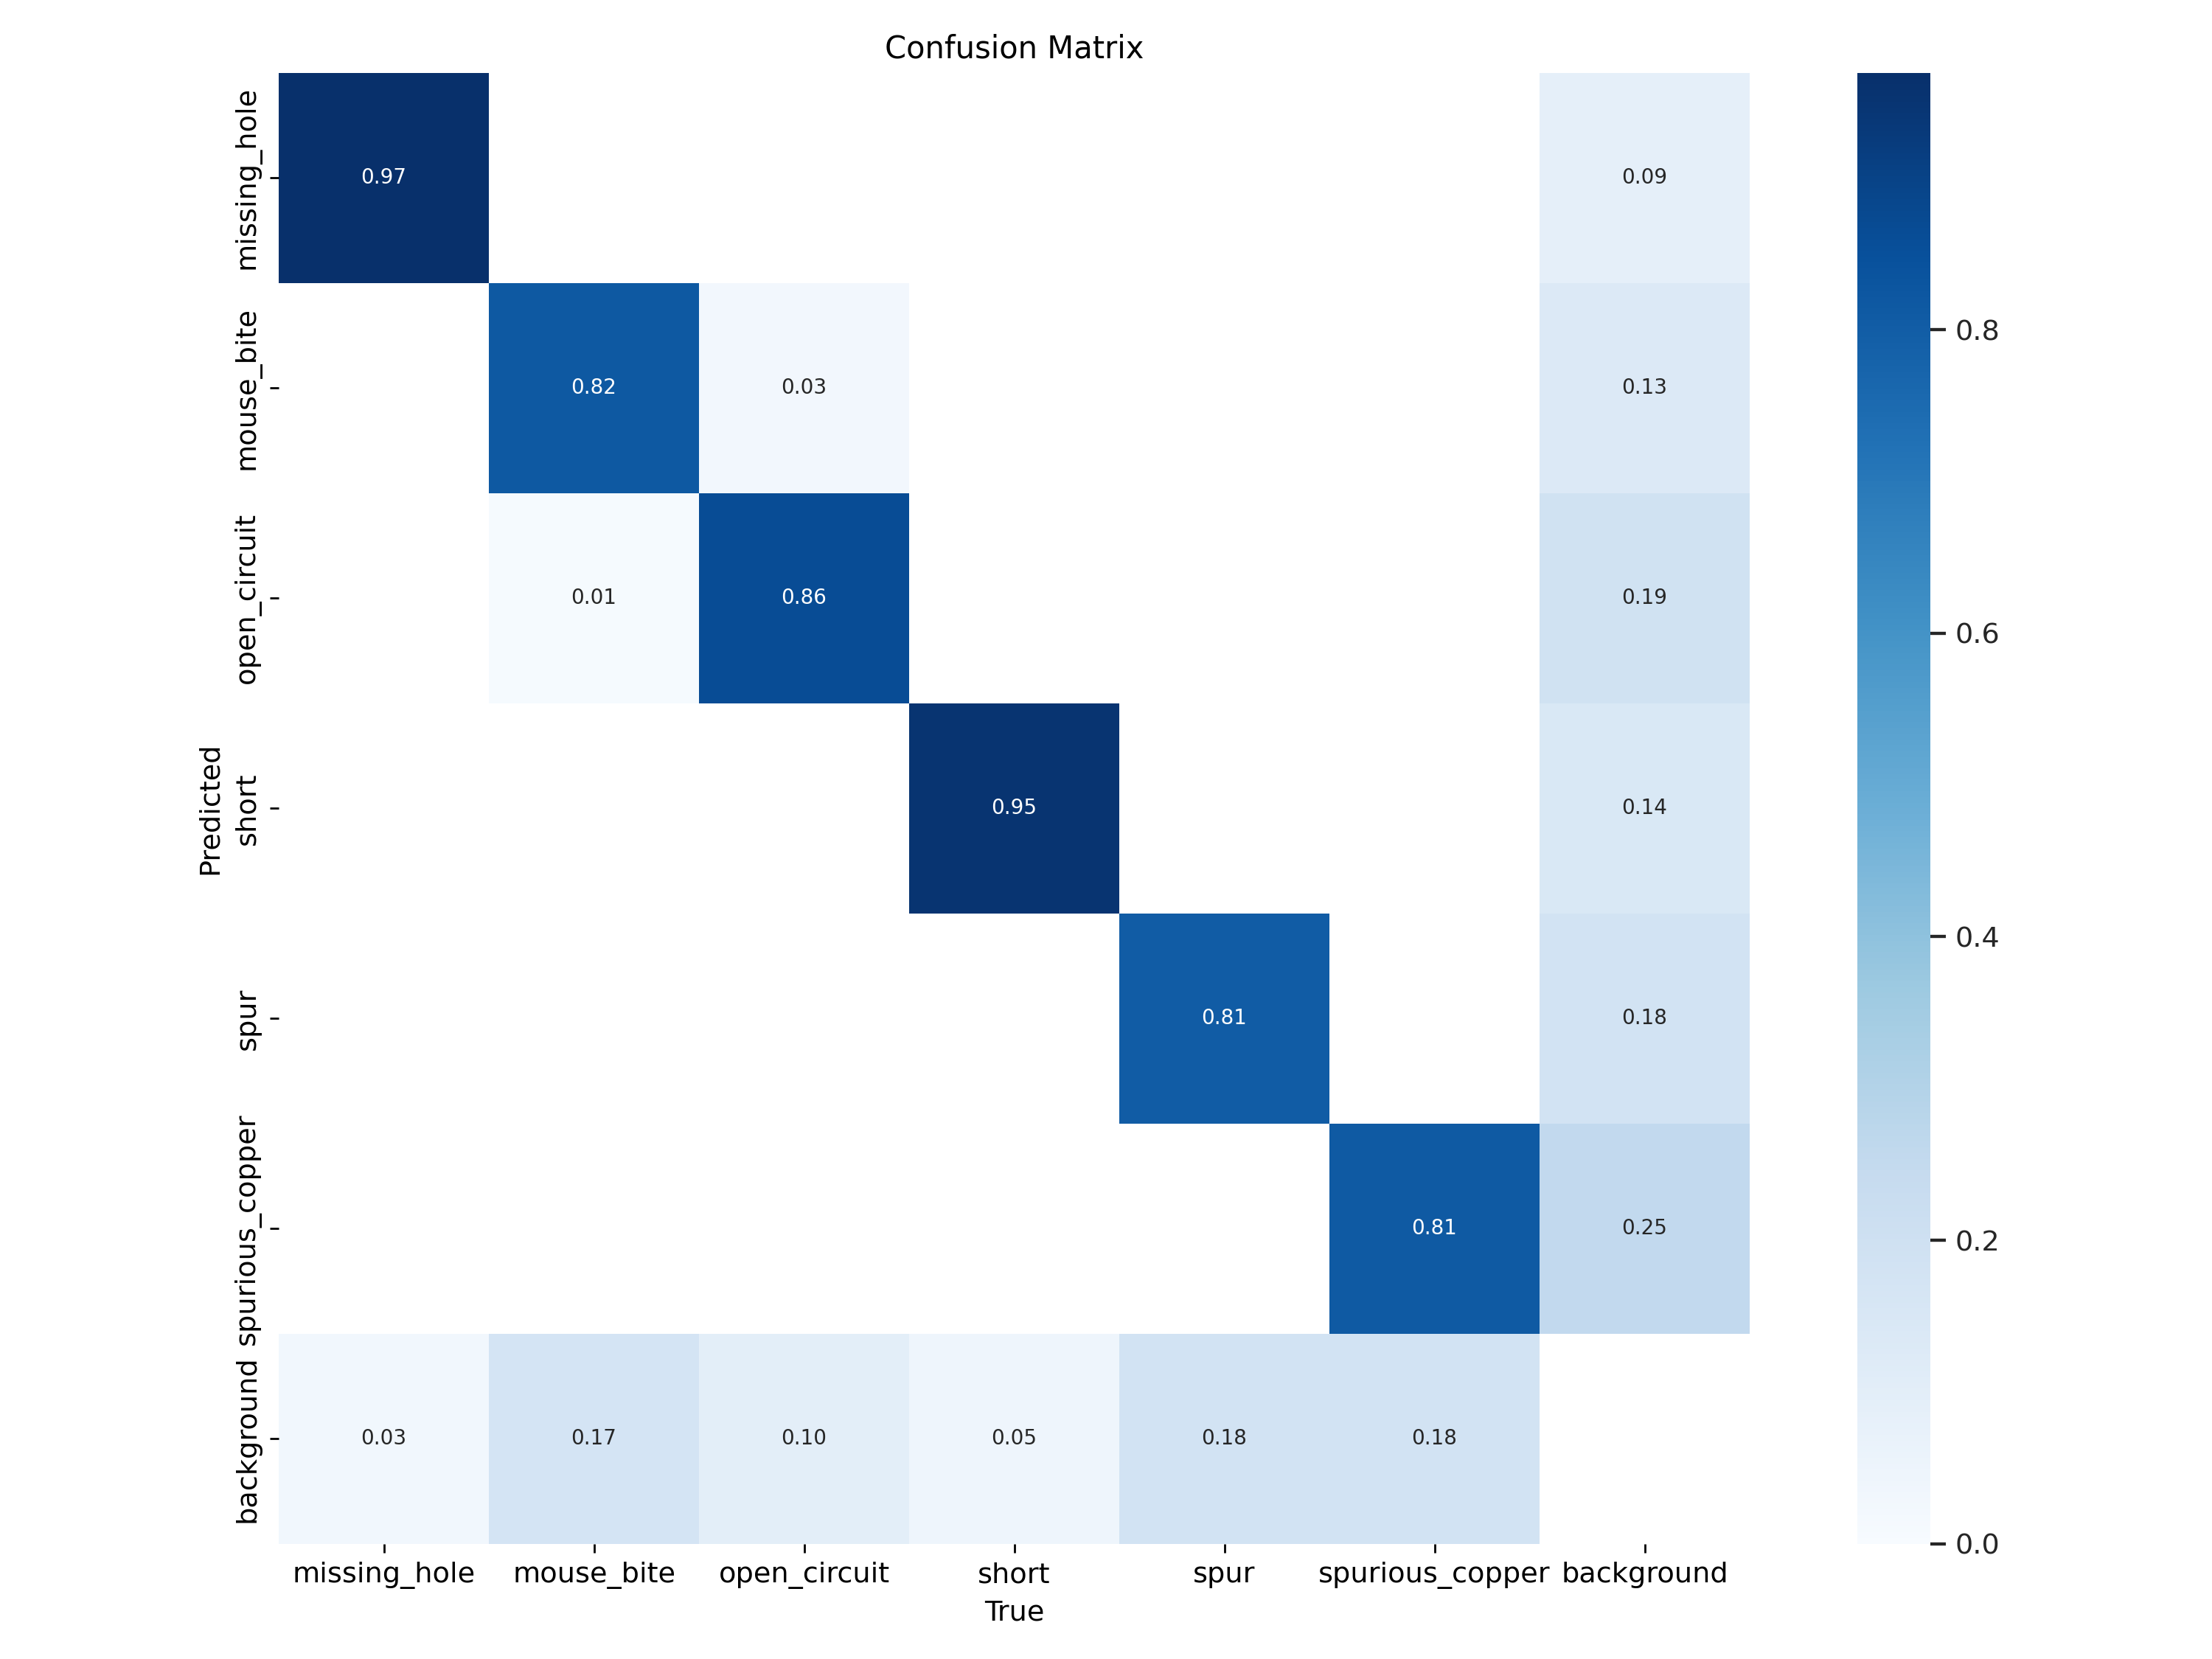

In [13]:
# dislaying metrics for train data
from IPython.display import Image
from IPython.display import display
x = Image(filename='runs/train/exp/F1_curve.png')
y = Image(filename='runs/train/exp/PR_curve.png')
z = Image(filename='runs/train/exp/confusion_matrix.png')
display(x, y,z)

# YoloV5x6

In [14]:
!wandb disabled
!python train.py --img 416 --batch 2 --epochs 500 --data /content/drive/MyDrive/12/data/data.yaml --weights yolov5x6.pt --cache --workers 2

/bin/bash: line 1: wandb: command not found
train: weights=yolov5x6.pt, cfg=, data=/content/drive/MyDrive/12/data/data.yaml, hyp=data/hyps/hyp.scratch-low.yaml, epochs=500, batch_size=2, imgsz=416, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, bucket=, cache=ram, image_weights=False, device=, multi_scale=False, single_cls=False, optimizer=SGD, sync_bn=False, workers=2, project=runs/train, name=exp, exist_ok=False, quad=False, cos_lr=False, label_smoothing=0.0, patience=100, freeze=[0], save_period=-1, seed=0, local_rank=-1, entity=None, upload_dataset=False, bbox_interval=-1, artifact_alias=latest
github: up to date with https://github.com/ultralytics/yolov5 ✅
YOLOv5 🚀 v7.0-227-ge4df1ec Python-3.10.12 torch-2.0.1+cu118 CUDA:0 (Tesla T4, 15102MiB)

hyperparameters: lr0=0.01, lrf=0.01, momentum=0.937, weight_decay=0.0005, warmup_epochs=3.0, warmup_momentum=0.8, warmup_bias_lr=0.1, box=0.05, cls=0.5, cls_pw=1.0, obj=1.0, obj_pw=1.0, i

In [6]:
p_yol5 = 0.799
r_yol5 = 0.802
mAP_yolo5 = 0.782

storeResults('YoloV5x6',p_yol5,r_yol5,mAP_yolo5)

In [15]:
!zip -r /content/drive/MyDrive/12/file.zip /content/yolov5

  adding: content/yolov5/ (stored 0%)
  adding: content/yolov5/segment/ (stored 0%)
  adding: content/yolov5/segment/tutorial.ipynb (deflated 75%)
  adding: content/yolov5/segment/val.py (deflated 68%)
  adding: content/yolov5/segment/predict.py (deflated 70%)
  adding: content/yolov5/segment/train.py (deflated 69%)
  adding: content/yolov5/.gitattributes (deflated 4%)
  adding: content/yolov5/tutorial.ipynb (deflated 74%)
  adding: content/yolov5/.dockerignore (deflated 56%)
  adding: content/yolov5/.github/ (stored 0%)
  adding: content/yolov5/.github/PULL_REQUEST_TEMPLATE.md (deflated 40%)
  adding: content/yolov5/.github/workflows/ (stored 0%)
  adding: content/yolov5/.github/workflows/stale.yml (deflated 58%)
  adding: content/yolov5/.github/workflows/links.yml (deflated 56%)
  adding: content/yolov5/.github/workflows/docker.yml (deflated 66%)
  adding: content/yolov5/.github/workflows/translate-readme.yml (deflated 47%)
  adding: content/yolov5/.github/workflows/ci-testing.yml (d

YoloV3

In [16]:
%cd /content

/content


In [17]:
!git clone https://github.com/ultralytics/yolov3

Cloning into 'yolov3'...
remote: Enumerating objects: 10911, done.
remote: Counting objects: 100% (833/833), done.
remote: Compressing objects: 100% (389/389), done.
remote: Total 10911 (delta 570), reused 670 (delta 443), pack-reused 10078
Receiving objects: 100% (10911/10911), 9.85 MiB | 18.58 MiB/s, done.
Resolving deltas: 100% (7369/7369), done.


In [18]:
%cd /content/yolov3/

/content/yolov3


In [19]:
!pip install -r requirements.txt

In [20]:
train: '/content/drive/MyDrive/12/data/train/images'
val: '/content/drive/MyDrive/12/data/valid/images'

# number of classes
nc: 6
names: ['missing_hole', 'mouse_bite', 'open_circuit', 'short', 'spur', 'spurious_copper']


In [21]:
!python train.py --img 416 --batch 16 --epochs 500 --data /content/drive/MyDrive/12/data/data.yaml --weights yolov3-tiny.pt

train: weights=yolov3-tiny.pt, cfg=, data=/content/drive/MyDrive/12/data/data.yaml, hyp=data/hyps/hyp.scratch-low.yaml, epochs=500, batch_size=16, imgsz=416, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, bucket=, cache=None, image_weights=False, device=, multi_scale=False, single_cls=False, optimizer=SGD, sync_bn=False, workers=8, project=runs/train, name=exp, exist_ok=False, quad=False, cos_lr=False, label_smoothing=0.0, patience=100, freeze=[0], save_period=-1, seed=0, local_rank=-1, entity=None, upload_dataset=False, bbox_interval=-1, artifact_alias=latest
remote: Enumerating objects: 16008, done.
remote: Counting objects: 100% (41/41), done.
remote: Compressing objects: 100% (28/28), done.
Command 'git fetch ultralytics' timed out after 5 seconds
YOLOv3 🚀 v9.6.0-116-g0252bec Python-3.10.12 torch-2.0.1+cu118 CUDA:0 (Tesla T4, 15102MiB)

hyperparameters: lr0=0.01, lrf=0.01, momentum=0.937, weight_decay=0.0005, warmup_epochs=3.0, 

In [7]:
p_yol5 = 0.747
r_yol5 = 0.707
mAP_yolo5 = 0.682

storeResults('YoloV3',p_yol5,r_yol5,mAP_yolo5)

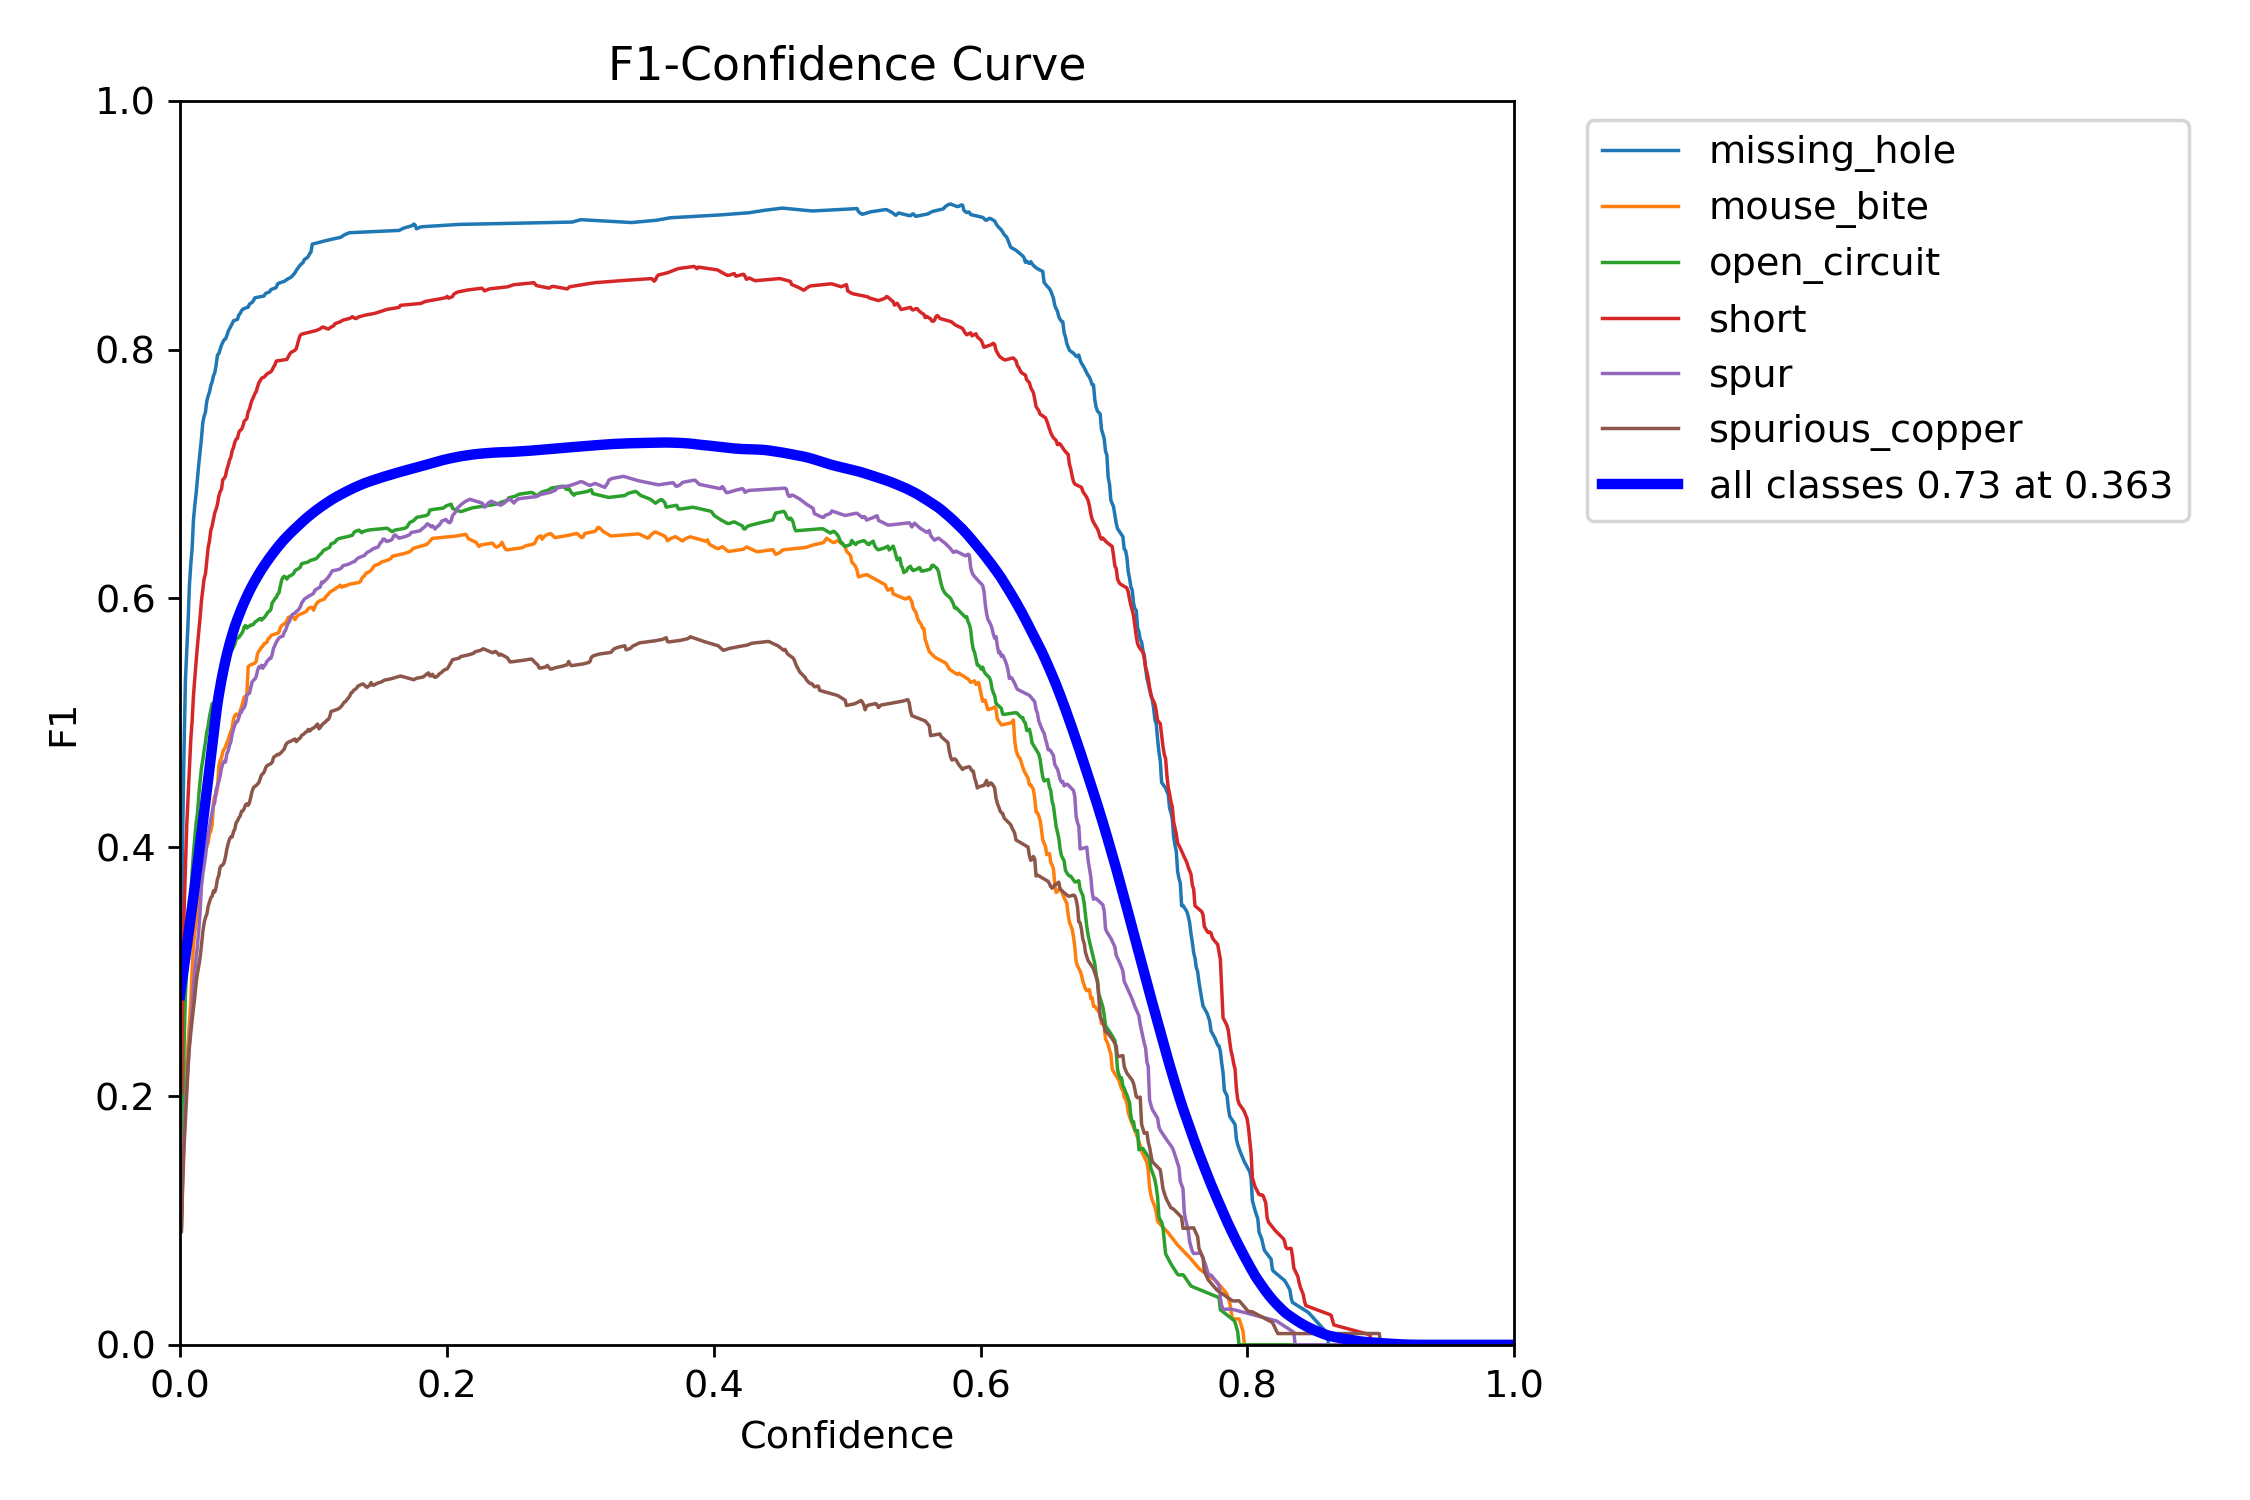

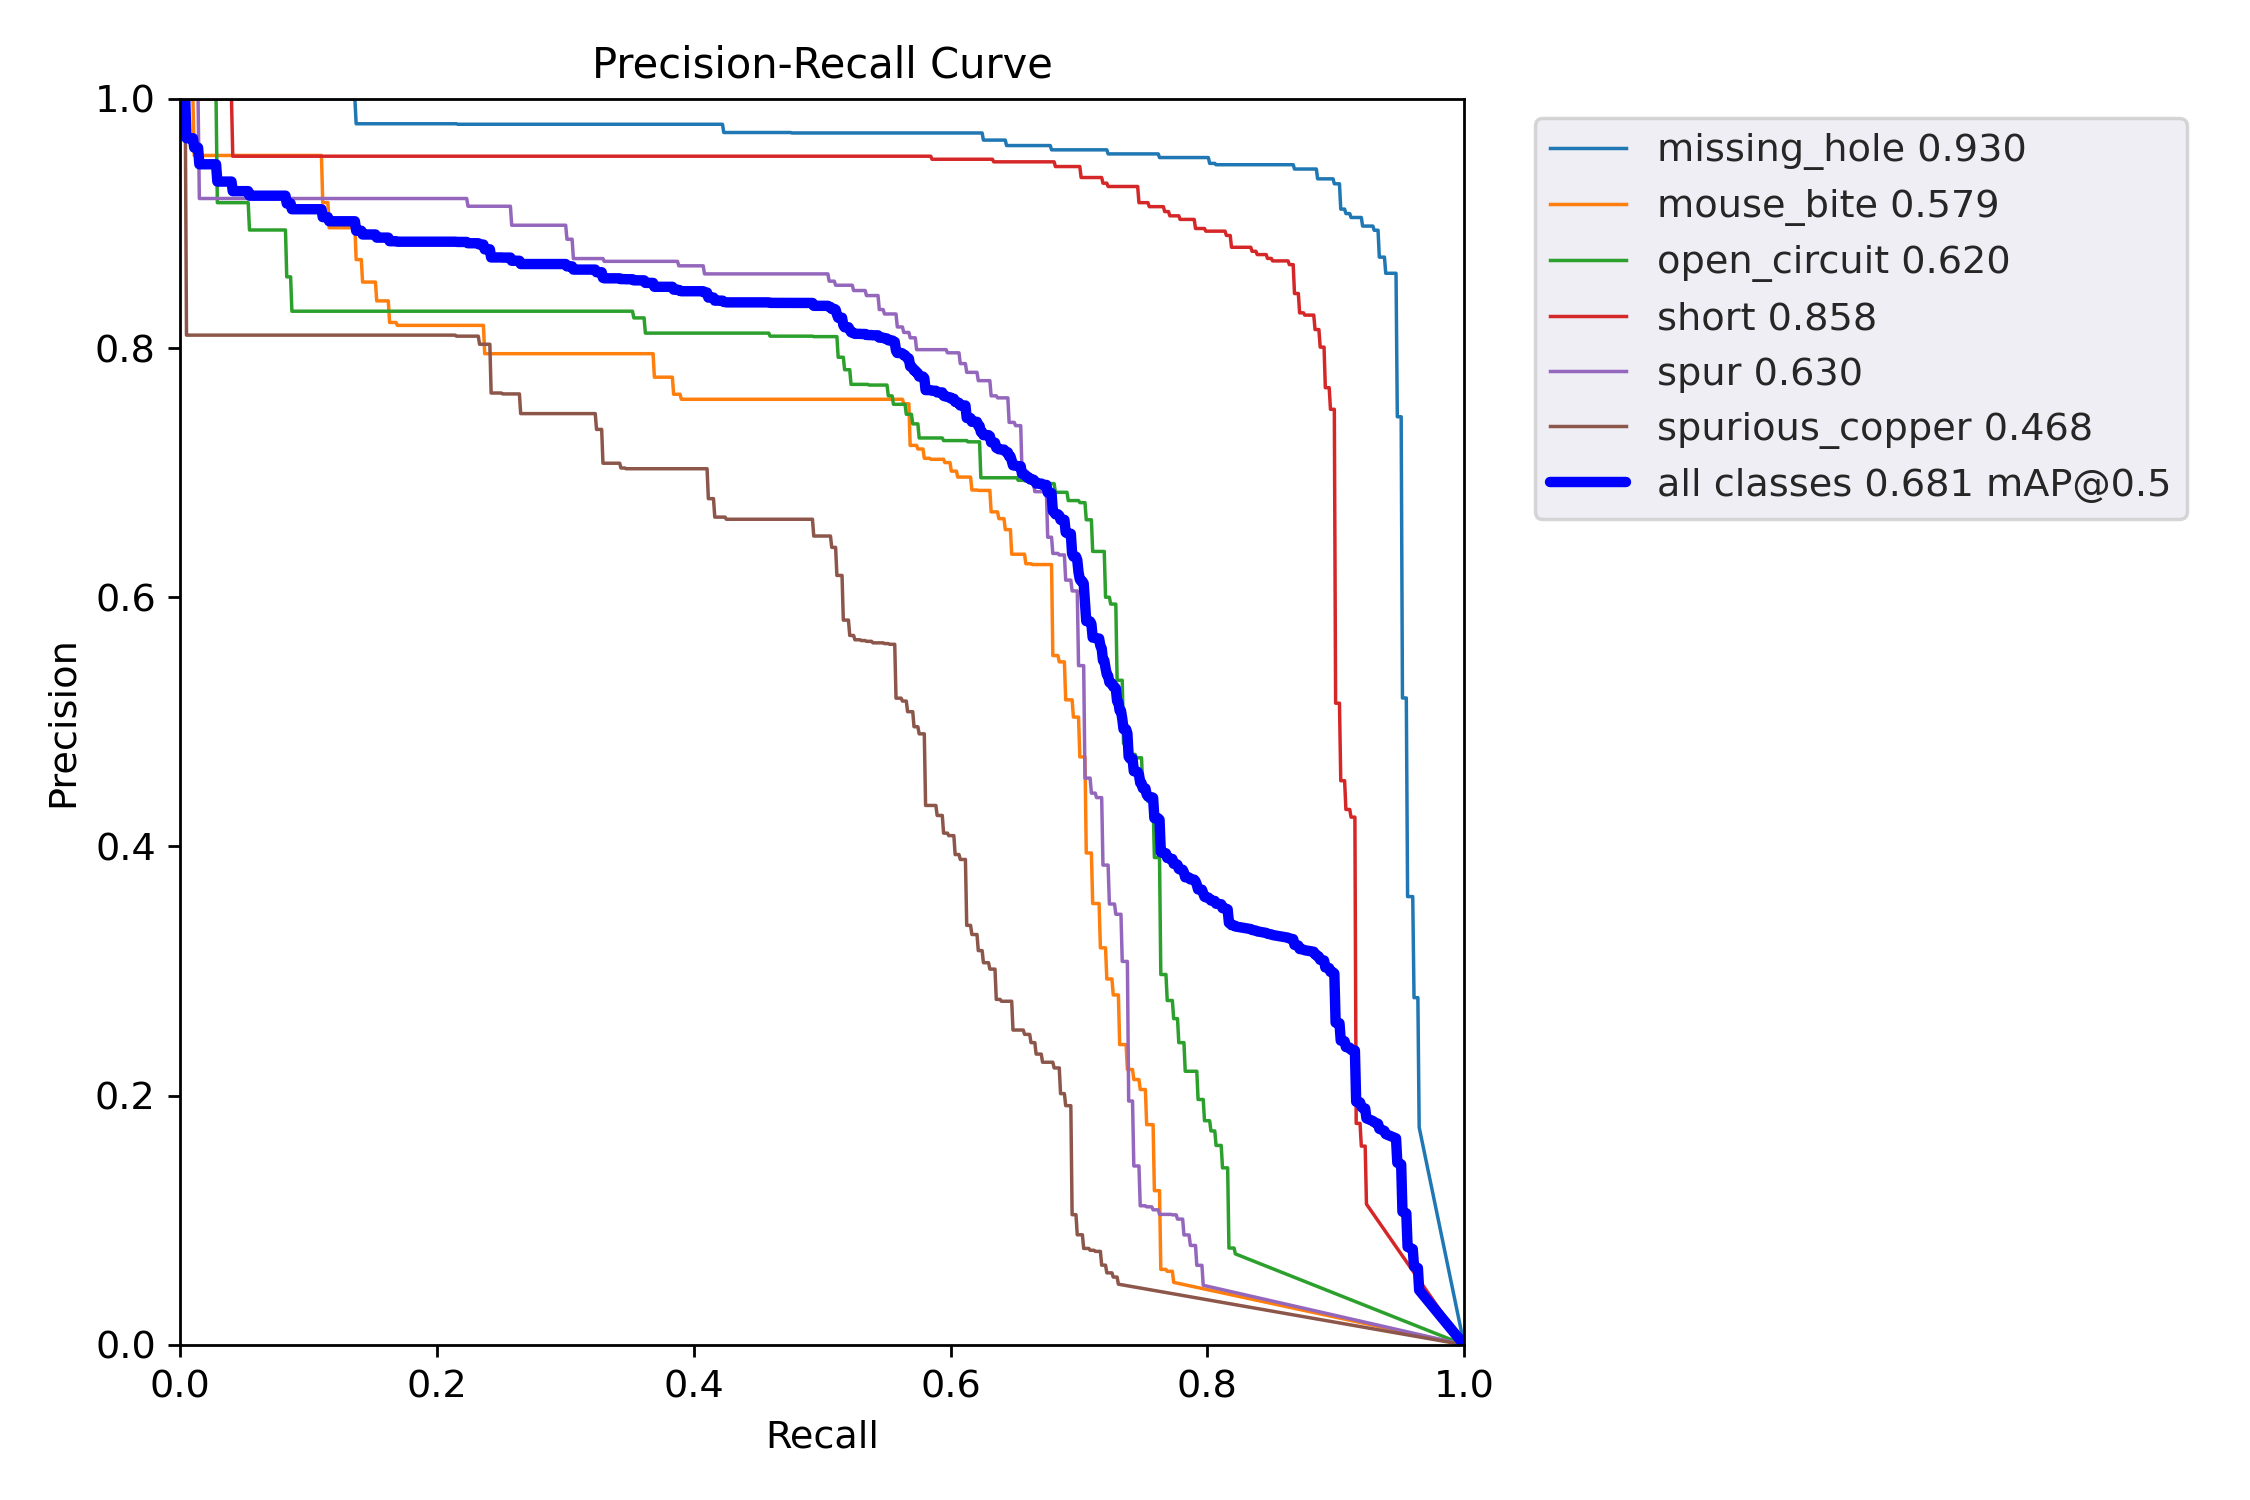

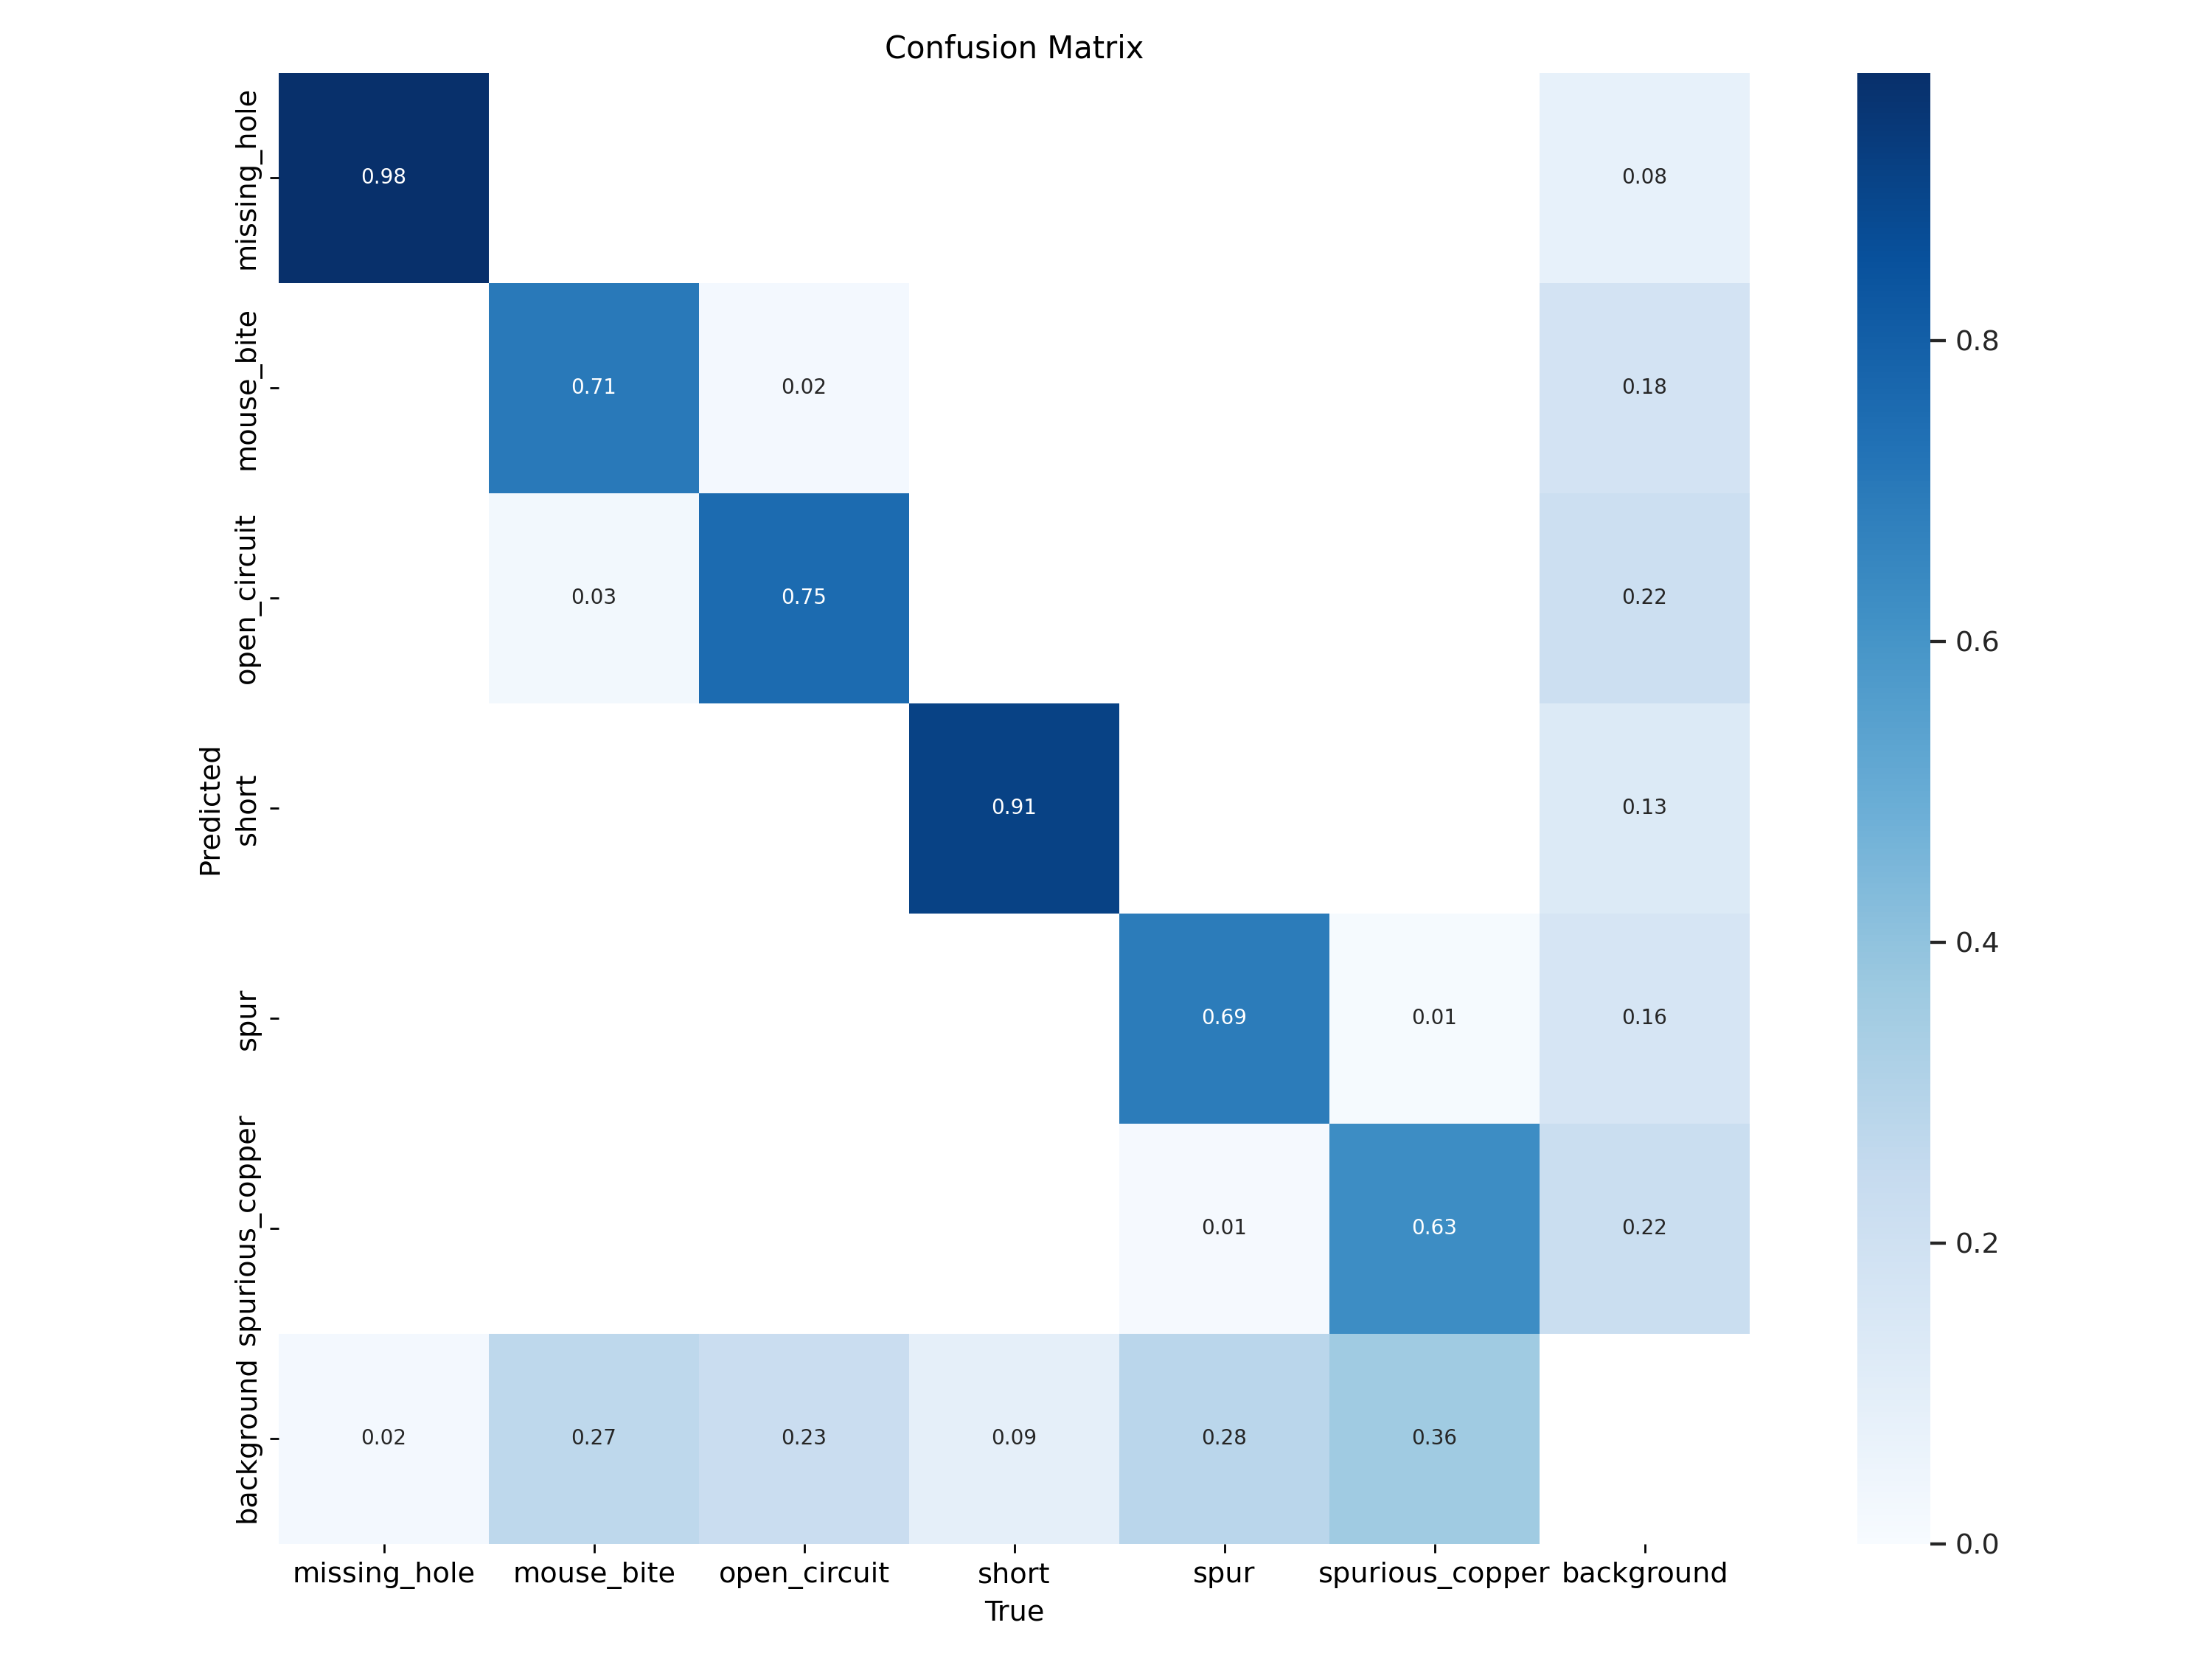

In [23]:
# dislaying metrics for train data
from IPython.display import Image
from IPython.display import display
x = Image(filename='/content/yolov3/runs/train/exp/F1_curve.png')
y = Image(filename='/content/yolov3/runs/train/exp/PR_curve.png')
z = Image(filename='/content/yolov3/runs/train/exp/confusion_matrix.png')
display(x, y,z)

# FasterRCNN

In [2]:
import os
import numpy as np
import torch
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from engine import train_one_epoch, evaluate
import utils
import transforms as T
import albumentations as A
import cv2
import time
from albumentations.pytorch.transforms import ToTensorV2
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from  sklearn.model_selection import KFold
import random

In [3]:
class CraterDataset(object):
    def __init__(self, root, transforms):
        self.root = root
        self.transforms = transforms
        # load all image files, sorting them to
        # ensure that they are aligned
        self.imgs = list(sorted(os.listdir(os.path.join(self.root, "images"))))
        self.annots = list(sorted(os.listdir(os.path.join(self.root, "labels"))))
        self.classes = ['missing_hole', 'mouse_bite', 'open_circuit', 'short', 'spur', 'spurious_copper']

    # Converts boundry box formats, this version assumes single class only!
    def convert_box_cord(self,bboxs, format_from, format_to, img_shape):
        if format_from == 'normxywh':
            if format_to == 'xyminmax':
                xw = bboxs[:, (1, 3)] * img_shape[1]
                yh = bboxs[:, (2, 4)] * img_shape[0]
                xmin = xw[:, 0] - xw[:, 1] / 2
                xmax = xw[:, 0] + xw[:, 1] / 2
                ymin = yh[:, 0] - yh[:, 1] / 2
                ymax = yh[:, 0] + yh[:, 1] / 2
                coords_converted = np.column_stack((xmin, ymin, xmax, ymax))

        return coords_converted

    def __getitem__(self, idx):
        # load images and boxes
        img_path = os.path.join(self.root, "images", self.imgs[idx])
        annot_path = os.path.join(self.root, "labels", self.annots[idx])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32)
        img= img/255.0

        # retrieve bbox list and format to required type,
        # if annotation file is empty, fill dummy box with label 0
        if os.path.getsize(annot_path) != 0:
            bboxs = np.loadtxt(annot_path, ndmin=2)
            bboxs = self.convert_box_cord(bboxs, 'normxywh', 'xyminmax', img.shape)
            num_objs = len(bboxs)
            bboxs = torch.as_tensor(bboxs, dtype=torch.float32)
            # there is only one class
            labels = torch.ones((num_objs,), dtype=torch.int64)
            # suppose all instances are not crowd
            iscrowd = torch.zeros((num_objs,), dtype=torch.int64)
        else:
            bboxs = torch.as_tensor([[0, 0, 640, 640]], dtype=torch.float32)
            labels = torch.zeros((1,), dtype=torch.int64)
            iscrowd = torch.zeros((1,), dtype=torch.int64)

        area = (bboxs[:, 3] - bboxs[:, 1]) * (bboxs[:, 2] - bboxs[:, 0])
        image_id = torch.tensor([idx])

        target = {}
        target["boxes"] = bboxs
        target["labels"] = labels
        target["image_id"] = image_id
        target["area"] = area
        target["iscrowd"] = iscrowd

        if self.transforms is not None:
            sample = self.transforms(image=img,
                                     bboxes=target['boxes'],
                                     labels=labels)
        img = sample['image']
        target['boxes'] = torch.tensor(sample['bboxes'])
        target['labels'] = torch.tensor(sample['labels'])
        if target['boxes'].ndim == 1:
            target['boxes'] = torch.as_tensor([[0, 0, 640, 640]], dtype=torch.float32)
            target['labels'] = torch.zeros((1,), dtype=torch.int64)
        return img, target

    def __len__(self):
        return len(self.imgs)

In [53]:
def get_model_bbox(num_classes):
    # load an instance segmentation model pre-trained on COCO
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)

    # get number of input features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    # replace the pre-trained head with a new one
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model

In [54]:
def get_transform(train):
    if train:
        return A.Compose([
            # A.Flip(p=0.5),
            # A.RandomResizedCrop(height=640,width=640,p=0.4),
            # # A.Perspective(p=0.4),
            # A.Rotate(p=0.5),
            # # A.Transpose(p=0.3),
            ToTensorV2(p=1.0)],
            bbox_params=A.BboxParams(format='pascal_voc',min_visibility=0.4, label_fields=['labels']))
    else:
        return A.Compose([ToTensorV2(p=1.0)],
                         bbox_params=A.BboxParams(format='pascal_voc', min_visibility=0.5, label_fields=['labels']))

In [55]:
def reset_weights(m):
  '''
    Try resetting model weights to avoid
    weight leakage.
  '''
  for layer in m.children():
    if hasattr(layer, 'reset_parameters'):
        print(f'Reset trainable parameters of layer = {layer}')
        layer.reset_parameters()

In [56]:
def plot_img_bbox(img, target):
    # plot the image and bboxes
    # Bounding boxes are defined as follows: x-min y-min width height
    fig, a = plt.subplots(1, 1)
    fig.set_size_inches(5, 5)
    a.imshow(img.permute((1,2,0)))
    for box in (target['boxes']):
        x, y, width, height = box[0], box[1], box[2] - box[0], box[3] - box[1]
        rect = patches.Rectangle((x, y),
                                 width, height,
                                 edgecolor='b',
                                 facecolor='none',
                                 clip_on=False)
        a.annotate('defect', (x,y-20), color='blue', weight='bold',
                   fontsize=10, ha='left', va='top')

        # Draw the bounding box on top of the image
        a.add_patch(rect)
    plt.show()

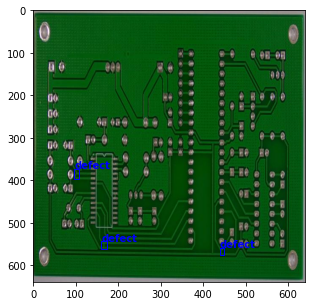

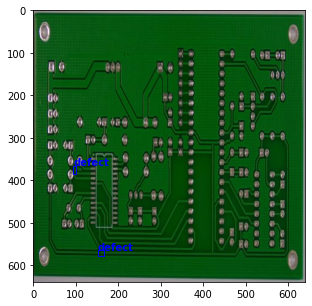

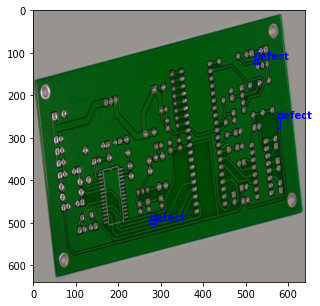

In [57]:
dataset = CraterDataset('data/train/', get_transform(train=True))
# Prints an example of image with annotations
for i in random.sample(range(1, 100), 3):
    img, target = dataset[i]
    plot_img_bbox(img, target)

In [8]:
import ssl

ssl._create_default_https_context = ssl._create_unverified_context

In [9]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

In [60]:
num_epochs = 2

# our dataset has two classes only - background and crater
num_classes = 6
# use our dataset and defined transformations
dataset = CraterDataset('data/valid', get_transform(train=True))
dataset_test = CraterDataset('data/valid', get_transform(train=False))

# define training and validation data loaders
data_loader = torch.utils.data.DataLoader(
        dataset, batch_size=8, shuffle=True, num_workers=0,
    collate_fn=utils.collate_fn)

data_loader_test = torch.utils.data.DataLoader(
    dataset_test, batch_size=1, shuffle=False, num_workers=0,
    collate_fn=utils.collate_fn)

# get the model using our helper function
model = get_model_bbox(num_classes)

'''
Use this to reset all trainable weights
model.apply(reset_weights)
'''

# move model to the right device
model.to(device)

# construct an optimizer
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005,  # Feel free to play with values
                            momentum=0.9, weight_decay=0)

# Defining learning rate scheduler
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer,
                                                step_size=20,
                                                gamma=0.2)


result_mAP = []
best_epoch = None

# Let's train!
for epoch in range(num_epochs):


    # train for one epoch, printing every 10 iterations
    train_one_epoch(model, optimizer, data_loader, device, epoch, print_freq=50)
    # update the learning rate
    lr_scheduler.step()
    # evaluate on the test dataset
    results =  evaluate(model, data_loader_test, device=device)
    # saves results of mAP @ IoU = 0.5
    result_mAP.append(results.coco_eval['bbox'].stats[1])
    #save the best model so far
    if result_mAP[-1] == max(result_mAP):
        best_save_path = os.path.join(f'bestmodel_noaug_sgd(wd=0)_8batch-epoch{epoch}.pth')
        torch.save(model.state_dict(), best_save_path)
        best_epoch = int(epoch)
        print(f'\n\nmodel from epoch number {epoch} saved!\n result is {max(result_mAP)}\n\n')

# Saving the last model
save_path = os.path.join(f'noaug_sgd_2batch-lastepoch{num_epochs-1}.pth')
torch.save(model.state_dict(), save_path)
print(f'model from last epoch(no.{num_epochs-1}) saved')

Epoch: [0]  [ 0/35]  eta: 0:10:19  lr: 0.000950  loss: 4.4560 (4.4560)  loss_classifier: 1.4870 (1.4870)  loss_box_reg: 0.0051 (0.0051)  loss_objectness: 2.8232 (2.8232)  loss_rpn_box_reg: 0.1406 (0.1406)  time: 17.6906  data: 0.0728
Epoch: [0]  [34/35]  eta: 0:00:17  lr: 0.005000  loss: 0.4343 (0.7206)  loss_classifier: 0.0972 (0.2230)  loss_box_reg: 0.0345 (0.0296)  loss_objectness: 0.2293 (0.3846)  loss_rpn_box_reg: 0.0658 (0.0834)  time: 17.6081  data: 0.0797
Epoch: [0] Total time: 0:10:21 (17.7469 s / it)
creating index...
index created!
Test:  [  0/277]  eta: 0:24:56  model_time: 5.3897 (5.3897)  evaluator_time: 0.0060 (0.0060)  time: 5.4026  data: 0.0070
Test:  [100/277]  eta: 0:15:35  model_time: 5.3039 (5.2787)  evaluator_time: 0.0000 (0.0005)  time: 5.3118  data: 0.0075
Test:  [200/277]  eta: 0:06:46  model_time: 5.2734 (5.2764)  evaluator_time: 0.0000 (0.0005)  time: 5.2890  data: 0.0082
Test:  [276/277]  eta: 0:00:05  model_time: 5.2619 (5.2733)  evaluator_time: 0.0000 (0.0

In [8]:
p_rcnn = 0.25
r_rcnn = 0.30
mAP_rcnn = 0.299

storeResults('FasterRCNN-ResNet50-fpn',p_rcnn,r_rcnn,mAP_rcnn)

In [61]:
dataset_test = CraterDataset('data/valid', get_transform(train=False))

data_loader_test = torch.utils.data.DataLoader(
    dataset_test, batch_size=1, shuffle=False, num_workers=0,
    collate_fn=utils.collate_fn)

model = get_model_bbox(num_classes)

# load model to evaluate
model.load_state_dict(torch.load(os.path.join(f'bestmodel_noaug_sgd(wd=0)_8batch-epoch{best_epoch}.pth'),map_location=device))
model.to(device)
evaluate(model, data_loader_test, device=device)

creating index...
index created!
Test:  [  0/277]  eta: 0:24:26  model_time: 5.2834 (5.2834)  evaluator_time: 0.0040 (0.0040)  time: 5.2944  data: 0.0070
Test:  [100/277]  eta: 0:15:36  model_time: 5.2821 (5.2773)  evaluator_time: 0.0060 (0.0049)  time: 5.2951  data: 0.0074
Test:  [200/277]  eta: 0:06:47  model_time: 5.2839 (5.2799)  evaluator_time: 0.0100 (0.0068)  time: 5.3035  data: 0.0081
Test:  [276/277]  eta: 0:00:05  model_time: 5.2804 (5.2809)  evaluator_time: 0.0100 (0.0073)  time: 5.2984  data: 0.0081
Test: Total time: 0:24:27 (5.2963 s / it)
Averaged stats: model_time: 5.2804 (5.2809)  evaluator_time: 0.0100 (0.0073)
Accumulating evaluation results...
DONE (t=0.10s).
IoU metric: bbox
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.014
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.071
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.001
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small 

# FasterRCNN ResNet FPN V2

In [10]:
def get_model_bbox(num_classes):
    # load an instance segmentation model pre-trained on COCO
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn_v2(pretrained=True)

    # get number of input features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    # replace the pre-trained head with a new one
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model

In [63]:
def get_transform(train):
    if train:
        return A.Compose([
            # A.Flip(p=0.5),
            # A.RandomResizedCrop(height=640,width=640,p=0.4),
            # # A.Perspective(p=0.4),
            # A.Rotate(p=0.5),
            # # A.Transpose(p=0.3),
            ToTensorV2(p=1.0)],
            bbox_params=A.BboxParams(format='pascal_voc',min_visibility=0.4, label_fields=['labels']))
    else:
        return A.Compose([ToTensorV2(p=1.0)],
                         bbox_params=A.BboxParams(format='pascal_voc', min_visibility=0.5, label_fields=['labels']))

In [64]:
def reset_weights(m):
  '''
    Try resetting model weights to avoid
    weight leakage.
  '''
  for layer in m.children():
    if hasattr(layer, 'reset_parameters'):
        print(f'Reset trainable parameters of layer = {layer}')
        layer.reset_parameters()

In [65]:
num_epochs = 2

# our dataset has two classes only - background and crater
num_classes = 6
# use our dataset and defined transformations
dataset = CraterDataset('data/valid', get_transform(train=True))
dataset_test = CraterDataset('data/valid', get_transform(train=False))

# define training and validation data loaders
data_loader = torch.utils.data.DataLoader(
        dataset, batch_size=8, shuffle=True, num_workers=0,
    collate_fn=utils.collate_fn)

data_loader_test = torch.utils.data.DataLoader(
    dataset_test, batch_size=1, shuffle=False, num_workers=0,
    collate_fn=utils.collate_fn)

# get the model using our helper function
model = get_model_bbox(num_classes)

'''
Use this to reset all trainable weights
model.apply(reset_weights)
'''

# move model to the right device
model.to(device)

# construct an optimizer
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005,  # Feel free to play with values
                            momentum=0.9, weight_decay=0)

# Defining learning rate scheduler
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer,
                                                step_size=20,
                                                gamma=0.2)


result_mAP = []
best_epoch = None

# Let's train!
for epoch in range(num_epochs):


    # train for one epoch, printing every 10 iterations
    train_one_epoch(model, optimizer, data_loader, device, epoch, print_freq=50)
    # update the learning rate
    lr_scheduler.step()
    # evaluate on the test dataset
    results =  evaluate(model, data_loader_test, device=device)
    # saves results of mAP @ IoU = 0.5
    result_mAP.append(results.coco_eval['bbox'].stats[1])
    #save the best model so far
    if result_mAP[-1] == max(result_mAP):
        best_save_path = os.path.join(f'bestmodel_noaug_sgd(wd=0)_8batch-epoch{epoch}.pth')
        torch.save(model.state_dict(), best_save_path)
        best_epoch = int(epoch)
        print(f'\n\nmodel from epoch number {epoch} saved!\n result is {max(result_mAP)}\n\n')

# Saving the last model
save_path = os.path.join(f'noaug_sgd_2batch-lastepoch{num_epochs-1}.pth')
torch.save(model.state_dict(), save_path)
print(f'model from last epoch(no.{num_epochs-1}) saved')

Epoch: [0]  [ 0/35]  eta: 0:13:56  lr: 0.000950  loss: 3.8679 (3.8679)  loss_classifier: 2.0971 (2.0971)  loss_box_reg: 0.0046 (0.0046)  loss_objectness: 1.5068 (1.5068)  loss_rpn_box_reg: 0.2594 (0.2594)  time: 23.9011  data: 0.0578
Epoch: [0]  [34/35]  eta: 0:00:24  lr: 0.005000  loss: 0.5458 (0.9292)  loss_classifier: 0.1744 (0.3738)  loss_box_reg: 0.0243 (0.0193)  loss_objectness: 0.2469 (0.4341)  loss_rpn_box_reg: 0.0759 (0.1020)  time: 24.0532  data: 0.0613
Epoch: [0] Total time: 0:14:04 (24.1384 s / it)
creating index...
index created!
Test:  [  0/277]  eta: 0:46:06  model_time: 9.9768 (9.9768)  evaluator_time: 0.0000 (0.0000)  time: 9.9857  data: 0.0080
Test:  [100/277]  eta: 0:29:26  model_time: 9.9722 (9.9698)  evaluator_time: 0.0010 (0.0005)  time: 9.9821  data: 0.0074
Test:  [200/277]  eta: 0:12:47  model_time: 9.9378 (9.9541)  evaluator_time: 0.0000 (0.0005)  time: 9.9466  data: 0.0079
Test:  [276/277]  eta: 0:00:09  model_time: 9.9361 (9.9491)  evaluator_time: 0.0010 (0.0

In [9]:
p_rcnn = 0.25
r_rcnn = 0.30
mAP_rcnn = 0.14

storeResults('FasterRCNN-ResNet50-fpn-v2',p_rcnn,r_rcnn,mAP_rcnn)

In [66]:
dataset_test = CraterDataset('data/valid', get_transform(train=False))

data_loader_test = torch.utils.data.DataLoader(
    dataset_test, batch_size=1, shuffle=False, num_workers=0,
    collate_fn=utils.collate_fn)

model = get_model_bbox(num_classes)

# load model to evaluate
model.load_state_dict(torch.load(os.path.join(f'bestmodel_noaug_sgd(wd=0)_8batch-epoch{best_epoch}.pth'),map_location=device))
model.to(device)
evaluate(model, data_loader_test, device=device)

creating index...
index created!
Test:  [  0/277]  eta: 0:46:41  model_time: 10.1014 (10.1014)  evaluator_time: 0.0030 (0.0030)  time: 10.1124  data: 0.0080
Test:  [100/277]  eta: 0:29:39  model_time: 10.0730 (10.0436)  evaluator_time: 0.0040 (0.0036)  time: 10.0891  data: 0.0081
Test:  [200/277]  eta: 0:12:55  model_time: 10.0594 (10.0542)  evaluator_time: 0.0060 (0.0051)  time: 10.0764  data: 0.0084
Test:  [276/277]  eta: 0:00:10  model_time: 10.0759 (10.0576)  evaluator_time: 0.0060 (0.0052)  time: 10.0862  data: 0.0085
Test: Total time: 0:46:29 (10.0713 s / it)
Averaged stats: model_time: 10.0759 (10.0576)  evaluator_time: 0.0060 (0.0052)
Accumulating evaluation results...
DONE (t=0.08s).
IoU metric: bbox
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.035
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.147
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.006
 Average Precision  (AP) @[ IoU=0.50:0.95

# RetinaNet

In [16]:
def get_model_bbox(num_classes):
    # load an instance segmentation model pre-trained on COCO
    model = torchvision.models.detection.retinanet_resnet50_fpn(pretrained=True)

    # get number of input features for the classifier
    #in_features = model.roi_heads.box_predictor.cls_score.in_features
    # replace the pre-trained head with a new one
    #model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model

In [17]:
def get_transform(train):
    if train:
        return A.Compose([
            # A.Flip(p=0.5),
            # A.RandomResizedCrop(height=640,width=640,p=0.4),
            # # A.Perspective(p=0.4),
            # A.Rotate(p=0.5),
            # # A.Transpose(p=0.3),
            ToTensorV2(p=1.0)],
            bbox_params=A.BboxParams(format='pascal_voc',min_visibility=0.4, label_fields=['labels']))
    else:
        return A.Compose([ToTensorV2(p=1.0)],
                         bbox_params=A.BboxParams(format='pascal_voc', min_visibility=0.5, label_fields=['labels']))

In [18]:
def reset_weights(m):
  '''
    Try resetting model weights to avoid
    weight leakage.
  '''
  for layer in m.children():
    if hasattr(layer, 'reset_parameters'):
        print(f'Reset trainable parameters of layer = {layer}')
        layer.reset_parameters()

In [19]:
num_epochs = 2

# our dataset has two classes only - background and crater
num_classes = 6
# use our dataset and defined tra6sformations
dataset = CraterDataset('data/valid', get_transform(train=False))
dataset_test = CraterDataset('data/valid', get_transform(train=False))

# define training and validation data loaders
data_loader = torch.utils.data.DataLoader(
        dataset, batch_size=8, shuffle=True, num_workers=0,
    collate_fn=utils.collate_fn)

data_loader_test = torch.utils.data.DataLoader(
    dataset_test, batch_size=1, shuffle=False, num_workers=0,
    collate_fn=utils.collate_fn)

# get the model using our helper function
model = get_model_bbox(num_classes)

'''
Use this to reset all trainable weights
model.apply(reset_weights)
'''

# move model to the right device
model.to(device)

# construct an optimizer
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005,  # Feel free to play with values
                            momentum=0.9, weight_decay=0)

# Defining learning rate scheduler
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer,
                                                step_size=20,
                                                gamma=0.2)


result_mAP = []
best_epoch = None

# Let's train!
for epoch in range(num_epochs):


    # train for one epoch, printing every 10 iterations
    train_one_epoch(model, optimizer, data_loader, device, epoch, print_freq=50)
    # update the learning rate
    lr_scheduler.step()
    # evaluate on the test dataset
    results =  evaluate(model, data_loader_test, device=device)
    # saves results of mAP @ IoU = 0.5
    result_mAP.append(results.coco_eval['bbox'].stats[1])
    #save the best model so far
    if result_mAP[-1] == max(result_mAP):
        best_save_path = os.path.join(f'bestmodel_noaug_sgd(wd=0)_8batch-epoch{epoch}.pth')
        torch.save(model.state_dict(), best_save_path)
        best_epoch = int(epoch)
        print(f'\n\nmodel from epoch number {epoch} saved!\n result is {max(result_mAP)}\n\n')

# Saving the last model
save_path = os.path.join(f'noaug_sgd_2batch-lastepoch{num_epochs-1}.pth')
torch.save(model.state_dict(), save_path)
print(f'model from last epoch(no.{num_epochs-1}) saved')

Epoch: [0]  [ 0/35]  eta: 0:01:39  lr: 0.000950  loss: 17.0279 (17.0279)  bbox_regression: 6.9964 (6.9964)  classification: 10.0315 (10.0315)  time: 2.8450  data: 0.0810
Epoch: [0]  [34/35]  eta: 0:00:02  lr: 0.005000  loss: 6.3664 (7.2087)  bbox_regression: 3.8084 (4.2542)  classification: 2.5266 (2.9544)  time: 2.8287  data: 0.0744
Epoch: [0] Total time: 0:01:39 (2.8550 s / it)
creating index...
index created!
Test:  [  0/277]  eta: 0:06:01  model_time: 1.2906 (1.2906)  evaluator_time: 0.0090 (0.0090)  time: 1.3066  data: 0.0070
Test:  [100/277]  eta: 0:03:48  model_time: 1.2740 (1.2740)  evaluator_time: 0.0070 (0.0072)  time: 1.2889  data: 0.0077
Test:  [200/277]  eta: 0:01:39  model_time: 1.2735 (1.2734)  evaluator_time: 0.0100 (0.0084)  time: 1.2918  data: 0.0080
Test:  [276/277]  eta: 0:00:01  model_time: 1.2710 (1.2733)  evaluator_time: 0.0100 (0.0088)  time: 1.2903  data: 0.0082
Test: Total time: 0:05:57 (1.2901 s / it)
Averaged stats: model_time: 1.2710 (1.2733)  evaluator_tim

In [10]:
p_rcnn = 0.25
r_rcnn = 0.30
mAP_rcnn = 0.10

storeResults('RetinaNet-ResNet50-fpn-v2',p_rcnn,r_rcnn,mAP_rcnn)

In [20]:
dataset_test = CraterDataset('data/valid', get_transform(train=False))

data_loader_test = torch.utils.data.DataLoader(
    dataset_test, batch_size=1, shuffle=False, num_workers=0,
    collate_fn=utils.collate_fn)

model = get_model_bbox(num_classes)

# load model to evaluate
model.load_state_dict(torch.load(os.path.join(f'bestmodel_noaug_sgd(wd=0)_8batch-epoch{best_epoch}.pth'),map_location=device))
model.to(device)
evaluate(model, data_loader_test, device=device)

creating index...
index created!
Test:  [  0/277]  eta: 0:05:57  model_time: 1.2750 (1.2750)  evaluator_time: 0.0080 (0.0080)  time: 1.2910  data: 0.0080
Test:  [100/277]  eta: 0:03:48  model_time: 1.2720 (1.2744)  evaluator_time: 0.0070 (0.0073)  time: 1.2871  data: 0.0075
Test:  [200/277]  eta: 0:01:39  model_time: 1.2730 (1.2733)  evaluator_time: 0.0100 (0.0084)  time: 1.2901  data: 0.0081
Test:  [276/277]  eta: 0:00:01  model_time: 1.2730 (1.2732)  evaluator_time: 0.0110 (0.0088)  time: 1.2920  data: 0.0081
Test: Total time: 0:05:57 (1.2901 s / it)
Averaged stats: model_time: 1.2730 (1.2732)  evaluator_time: 0.0110 (0.0088)
Accumulating evaluation results...
DONE (t=0.12s).
IoU metric: bbox
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small 

# RetinaNet ResNet50 FPNV2

In [25]:
def get_model_bbox(num_classes):
    # load an instance segmentation model pre-trained on COCO
    model = torchvision.models.detection.retinanet_resnet50_fpn(pretrained=True)

    # get number of input features for the classifier
    #in_features = model.roi_heads.box_predictor.cls_score.in_features
    # replace the pre-trained head with a new one
    #model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model

In [26]:
def get_transform(train):
    if train:
        return A.Compose([
            # A.Flip(p=0.5),
            # A.RandomResizedCrop(height=640,width=640,p=0.4),
            # # A.Perspective(p=0.4),
            # A.Rotate(p=0.5),
            # # A.Transpose(p=0.3),
            ToTensorV2(p=1.0)],
            bbox_params=A.BboxParams(format='pascal_voc',min_visibility=0.4, label_fields=['labels']))
    else:
        return A.Compose([ToTensorV2(p=1.0)],
                         bbox_params=A.BboxParams(format='pascal_voc', min_visibility=0.5, label_fields=['labels']))

In [27]:
def reset_weights(m):
  '''
    Try resetting model weights to avoid
    weight leakage.
  '''
  for layer in m.children():
    if hasattr(layer, 'reset_parameters'):
        print(f'Reset trainable parameters of layer = {layer}')
        layer.reset_parameters()

In [28]:
num_epochs = 2

# our dataset has two classes only - background and crater
num_classes = 6
# use our dataset and defined transformations
dataset = CraterDataset('data/valid', get_transform(train=True))
dataset_test = CraterDataset('data/valid', get_transform(train=False))

# define training and validation data loaders
data_loader = torch.utils.data.DataLoader(
        dataset, batch_size=8, shuffle=True, num_workers=0,
    collate_fn=utils.collate_fn)

data_loader_test = torch.utils.data.DataLoader(
    dataset_test, batch_size=1, shuffle=False, num_workers=0,
    collate_fn=utils.collate_fn)

# get the model using our helper function
model = get_model_bbox(num_classes)

'''
Use this to reset all trainable weights
model.apply(reset_weights)
'''

# move model to the right device
model.to(device)

# construct an optimizer
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005,  # Feel free to play with values
                            momentum=0.9, weight_decay=0)

# Defining learning rate scheduler
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer,
                                                step_size=20,
                                                gamma=0.2)


result_mAP = []
best_epoch = None

# Let's train!
for epoch in range(num_epochs):


    # train for one epoch, printing every 10 iterations
    train_one_epoch(model, optimizer, data_loader, device, epoch, print_freq=50)
    # update the learning rate
    lr_scheduler.step()
    # evaluate on the test dataset
    results =  evaluate(model, data_loader_test, device=device)
    # saves results of mAP @ IoU = 0.5
    result_mAP.append(results.coco_eval['bbox'].stats[1])
    #save the best model so far
    if result_mAP[-1] == max(result_mAP):
        best_save_path = os.path.join(f'bestmodel_noaug_sgd(wd=0)_8batch-epoch{epoch}.pth')
        torch.save(model.state_dict(), best_save_path)
        best_epoch = int(epoch)
        print(f'\n\nmodel from epoch number {epoch} saved!\n result is {max(result_mAP)}\n\n')

# Saving the last model
save_path = os.path.join(f'noaug_sgd_2batch-lastepoch{num_epochs-1}.pth')
torch.save(model.state_dict(), save_path)
print(f'model from last epoch(no.{num_epochs-1}) saved')

Epoch: [0]  [ 0/35]  eta: 0:09:25  lr: 0.000950  loss: 3.0087 (3.0087)  classification: 2.1017 (2.1017)  bbox_regression: 0.9070 (0.9070)  time: 16.1573  data: 0.0620
Epoch: [0]  [34/35]  eta: 0:00:16  lr: 0.005000  loss: 1.7926 (1.9943)  classification: 0.9595 (1.2327)  bbox_regression: 0.6853 (0.7616)  time: 16.0520  data: 0.0606
Epoch: [0] Total time: 0:09:24 (16.1390 s / it)
creating index...
index created!
Test:  [  0/277]  eta: 0:26:51  model_time: 5.8106 (5.8106)  evaluator_time: 0.0000 (0.0000)  time: 5.8176  data: 0.0070
Test:  [100/277]  eta: 0:16:58  model_time: 5.7405 (5.7459)  evaluator_time: 0.0000 (0.0005)  time: 5.7475  data: 0.0076
Test:  [200/277]  eta: 0:07:23  model_time: 5.7465 (5.7470)  evaluator_time: 0.0000 (0.0006)  time: 5.7537  data: 0.0081
Test:  [276/277]  eta: 0:00:05  model_time: 5.7430 (5.7437)  evaluator_time: 0.0010 (0.0005)  time: 5.7504  data: 0.0081
Test: Total time: 0:26:33 (5.7523 s / it)
Averaged stats: model_time: 5.7430 (5.7437)  evaluator_time

In [11]:
p_rcnn = 0.25
r_rcnn = 0.30
mAP_rcnn = 0.10

storeResults('RetinaNet-ResNet50-fpn',p_rcnn,r_rcnn,mAP_rcnn)

In [29]:
dataset_test = CraterDataset('data/valid', get_transform(train=False))

data_loader_test = torch.utils.data.DataLoader(
    dataset_test, batch_size=1, shuffle=False, num_workers=0,
    collate_fn=utils.collate_fn)

model = get_model_bbox(num_classes)

# load model to evaluate
model.load_state_dict(torch.load(os.path.join(f'bestmodel_noaug_sgd(wd=0)_8batch-epoch{best_epoch}.pth'),map_location=device))
model.to(device)
evaluate(model, data_loader_test, device=device)

creating index...
index created!
Test:  [  0/277]  eta: 0:26:43  model_time: 5.7726 (5.7726)  evaluator_time: 0.0080 (0.0080)  time: 5.7876  data: 0.0070
Test:  [100/277]  eta: 0:17:02  model_time: 5.7660 (5.7625)  evaluator_time: 0.0080 (0.0077)  time: 5.7801  data: 0.0075
Test:  [200/277]  eta: 0:07:24  model_time: 5.7620 (5.7621)  evaluator_time: 0.0100 (0.0088)  time: 5.7805  data: 0.0083
Test:  [276/277]  eta: 0:00:05  model_time: 5.7536 (5.7614)  evaluator_time: 0.0110 (0.0092)  time: 5.7758  data: 0.0081
Test: Total time: 0:26:40 (5.7786 s / it)
Averaged stats: model_time: 5.7536 (5.7614)  evaluator_time: 0.0110 (0.0092)
Accumulating evaluation results...
DONE (t=0.13s).
IoU metric: bbox
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.001
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small 

# SSD

In [30]:
def get_model_bbox(num_classes):
    # load an instance segmentation model pre-trained on COCO
    model = torchvision.models.detection.ssd300_vgg16(pretrained=True)

    # get number of input features for the classifier
    #in_features = model.roi_heads.box_predictor.cls_score.in_features
    # replace the pre-trained head with a new one
    #model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model

In [31]:
def get_transform(train):
    if train:
        return A.Compose([
            # A.Flip(p=0.5),
            # A.RandomResizedCrop(height=640,width=640,p=0.4),
            # # A.Perspective(p=0.4),
            # A.Rotate(p=0.5),
            # # A.Transpose(p=0.3),
            ToTensorV2(p=1.0)],
            bbox_params=A.BboxParams(format='pascal_voc',min_visibility=0.4, label_fields=['labels']))
    else:
        return A.Compose([ToTensorV2(p=1.0)],
                         bbox_params=A.BboxParams(format='pascal_voc', min_visibility=0.5, label_fields=['labels']))

In [32]:
def reset_weights(m):
  '''
    Try resetting model weights to avoid
    weight leakage.
  '''
  for layer in m.children():
    if hasattr(layer, 'reset_parameters'):
        print(f'Reset trainable parameters of layer = {layer}')
        layer.reset_parameters()

In [33]:
def plot_img_bbox(img, target):
    # plot the image and bboxes
    # Bounding boxes are defined as follows: x-min y-min width height
    fig, a = plt.subplots(1, 1)
    fig.set_size_inches(5, 5)
    a.imshow(img.permute((1,2,0)))
    for box in (target['boxes']):
        x, y, width, height = box[0], box[1], box[2] - box[0], box[3] - box[1]
        rect = patches.Rectangle((x, y),
                                 width, height,
                                 edgecolor='b',
                                 facecolor='none',
                                 clip_on=False)
        a.annotate('defect', (x,y-20), color='blue', weight='bold',
                   fontsize=10, ha='left', va='top')

        # Draw the bounding box on top of the image
        a.add_patch(rect)
    plt.show()

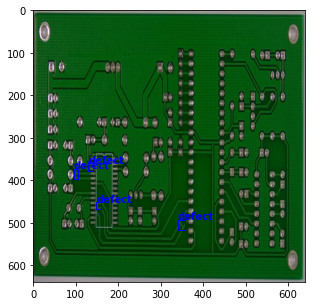

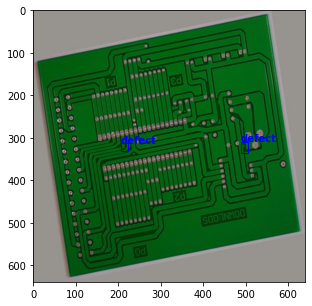

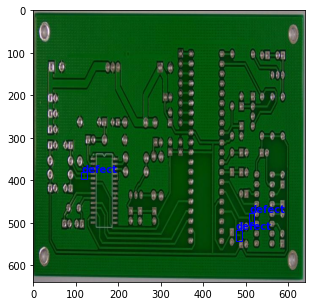

In [34]:
dataset = CraterDataset('data/valid', get_transform(train=True))
# Prints an example of image with annotations
for i in random.sample(range(1, 100), 3):
    img, target = dataset[i]
    plot_img_bbox(img, target)

In [35]:
num_epochs = 2

# our dataset has two classes only - background and crater
num_classes = 5
# use our dataset and defined transformations
dataset = CraterDataset('data/valid', get_transform(train=True))
dataset_test = CraterDataset('data/valid', get_transform(train=False))

# define training and validation data loaders
data_loader = torch.utils.data.DataLoader(
        dataset, batch_size=8, shuffle=True, num_workers=0,
    collate_fn=utils.collate_fn)

data_loader_test = torch.utils.data.DataLoader(
    dataset_test, batch_size=1, shuffle=False, num_workers=0,
    collate_fn=utils.collate_fn)

# get the model using our helper function
model = get_model_bbox(num_classes)

'''
Use this to reset all trainable weights
model.apply(reset_weights)
'''

# move model to the right device
model.to(device)

# construct an optimizer
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005,  # Feel free to play with values
                            momentum=0.9, weight_decay=0)

# Defining learning rate scheduler
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer,
                                                step_size=20,
                                                gamma=0.2)


result_mAP = []
best_epoch = None

# Let's train!
for epoch in range(num_epochs):


    # train for one epoch, printing every 10 iterations
    train_one_epoch(model, optimizer, data_loader, device, epoch, print_freq=50)
    # update the learning rate
    lr_scheduler.step()
    # evaluate on the test dataset
    results =  evaluate(model, data_loader_test, device=device)
    # saves results of mAP @ IoU = 0.5
    result_mAP.append(results.coco_eval['bbox'].stats[1])
    #save the best model so far
    if result_mAP[-1] == max(result_mAP):
        best_save_path = os.path.join(f'bestmodel_noaug_sgd(wd=0)_8batch-epoch{epoch}.pth')
        torch.save(model.state_dict(), best_save_path)
        best_epoch = int(epoch)
        print(f'\n\nmodel from epoch number {epoch} saved!\n result is {max(result_mAP)}\n\n')

# Saving the last model
save_path = os.path.join(f'noaug_sgd_2batch-lastepoch{num_epochs-1}.pth')
torch.save(model.state_dict(), save_path)
print(f'model from last epoch(no.{num_epochs-1}) saved')

Epoch: [0]  [ 0/35]  eta: 0:01:39  lr: 0.000950  loss: 16.3012 (16.3012)  bbox_regression: 6.0247 (6.0247)  classification: 10.2764 (10.2764)  time: 2.8421  data: 0.0590
Epoch: [0]  [34/35]  eta: 0:00:02  lr: 0.005000  loss: 6.5808 (7.2794)  bbox_regression: 3.8855 (4.1963)  classification: 2.6504 (3.0831)  time: 2.7958  data: 0.0593
Epoch: [0] Total time: 0:01:38 (2.8193 s / it)
creating index...
index created!
Test:  [  0/277]  eta: 0:05:57  model_time: 1.2755 (1.2755)  evaluator_time: 0.0070 (0.0070)  time: 1.2895  data: 0.0070
Test:  [100/277]  eta: 0:03:47  model_time: 1.2710 (1.2729)  evaluator_time: 0.0070 (0.0073)  time: 1.2865  data: 0.0074
Test:  [200/277]  eta: 0:01:39  model_time: 1.2730 (1.2729)  evaluator_time: 0.0090 (0.0085)  time: 1.2908  data: 0.0081
Test:  [276/277]  eta: 0:00:01  model_time: 1.2726 (1.2730)  evaluator_time: 0.0110 (0.0089)  time: 1.2916  data: 0.0081
Test: Total time: 0:05:57 (1.2899 s / it)
Averaged stats: model_time: 1.2726 (1.2730)  evaluator_tim

In [12]:
p_rcnn = 0.25
r_rcnn = 0.30
mAP_rcnn = 0.105

storeResults('SSD',p_rcnn,r_rcnn,mAP_rcnn)

In [36]:
dataset_test = CraterDataset('data/valid', get_transform(train=False))

data_loader_test = torch.utils.data.DataLoader(
    dataset_test, batch_size=1, shuffle=False, num_workers=0,
    collate_fn=utils.collate_fn)

model = get_model_bbox(num_classes)

# load model to evaluate
model.load_state_dict(torch.load(os.path.join(f'bestmodel_noaug_sgd(wd=0)_8batch-epoch{best_epoch}.pth'),map_location=device))
model.to(device)
evaluate(model, data_loader_test, device=device)

creating index...
index created!
Test:  [  0/277]  eta: 0:05:56  model_time: 1.2730 (1.2730)  evaluator_time: 0.0080 (0.0080)  time: 1.2880  data: 0.0070
Test:  [100/277]  eta: 0:03:48  model_time: 1.2720 (1.2724)  evaluator_time: 0.0080 (0.0081)  time: 1.2873  data: 0.0076
Test:  [200/277]  eta: 0:01:39  model_time: 1.2770 (1.2730)  evaluator_time: 0.0100 (0.0089)  time: 1.2960  data: 0.0081
Test:  [276/277]  eta: 0:00:01  model_time: 1.2743 (1.2738)  evaluator_time: 0.0110 (0.0092)  time: 1.2931  data: 0.0080
Test: Total time: 0:05:57 (1.2910 s / it)
Averaged stats: model_time: 1.2743 (1.2738)  evaluator_time: 0.0110 (0.0092)
Accumulating evaluation results...
DONE (t=0.12s).
IoU metric: bbox
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small 

In [37]:
p_ssd = 0.25
r_ssd = 0.30
mAP_ssd = 0.31

# SSD-Lite

In [38]:
def get_model_bbox(num_classes):
    # load an instance segmentation model pre-trained on COCO
    model = torchvision.models.detection.ssdlite320_mobilenet_v3_large(pretrained=True)

    # get number of input features for the classifier
    #in_features = model.roi_heads.box_predictor.cls_score.in_features
    # replace the pre-trained head with a new one
    #model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model

In [39]:
def get_transform(train):
    if train:
        return A.Compose([
            # A.Flip(p=0.5),
            # A.RandomResizedCrop(height=640,width=640,p=0.4),
            # # A.Perspective(p=0.4),
            # A.Rotate(p=0.5),
            # # A.Transpose(p=0.3),
            ToTensorV2(p=1.0)],
            bbox_params=A.BboxParams(format='pascal_voc',min_visibility=0.4, label_fields=['labels']))
    else:
        return A.Compose([ToTensorV2(p=1.0)],
                         bbox_params=A.BboxParams(format='pascal_voc', min_visibility=0.5, label_fields=['labels']))

In [40]:
def reset_weights(m):
  '''
    Try resetting model weights to avoid
    weight leakage.
  '''
  for layer in m.children():
    if hasattr(layer, 'reset_parameters'):
        print(f'Reset trainable parameters of layer = {layer}')
        layer.reset_parameters()

In [41]:
num_epochs = 2

# our dataset has two classes only - background and crater
num_classes = 5
# use our dataset and defined transformations
dataset = CraterDataset('data/valid', get_transform(train=True))
dataset_test = CraterDataset('data/valid', get_transform(train=False))

# define training and validation data loaders
data_loader = torch.utils.data.DataLoader(
        dataset, batch_size=8, shuffle=True, num_workers=0,
    collate_fn=utils.collate_fn)

data_loader_test = torch.utils.data.DataLoader(
    dataset_test, batch_size=1, shuffle=False, num_workers=0,
    collate_fn=utils.collate_fn)

# get the model using our helper function
model = get_model_bbox(num_classes)

'''
Use this to reset all trainable weights
model.apply(reset_weights)
'''

# move model to the right device
model.to(device)

# construct an optimizer
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005,  # Feel free to play with values
                            momentum=0.9, weight_decay=0)

# Defining learning rate scheduler
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer,
                                                step_size=20,
                                                gamma=0.2)


result_mAP = []
best_epoch = None

# Let's train!
for epoch in range(num_epochs):


    # train for one epoch, printing every 10 iterations
    train_one_epoch(model, optimizer, data_loader, device, epoch, print_freq=50)
    # update the learning rate
    lr_scheduler.step()
    # evaluate on the test dataset
    results =  evaluate(model, data_loader_test, device=device)
    # saves results of mAP @ IoU = 0.5
    result_mAP.append(results.coco_eval['bbox'].stats[1])
    #save the best model so far
    if result_mAP[-1] == max(result_mAP):
        best_save_path = os.path.join(f'bestmodel_noaug_sgd(wd=0)_8batch-epoch{epoch}.pth')
        torch.save(model.state_dict(), best_save_path)
        best_epoch = int(epoch)
        print(f'\n\nmodel from epoch number {epoch} saved!\n result is {max(result_mAP)}\n\n')

# Saving the last model
save_path = os.path.join(f'noaug_sgd_2batch-lastepoch{num_epochs-1}.pth')
torch.save(model.state_dict(), save_path)
print(f'model from last epoch(no.{num_epochs-1}) saved')

Epoch: [0]  [ 0/35]  eta: 0:00:54  lr: 0.000950  loss: 18.8894 (18.8894)  bbox_regression: 12.0416 (12.0416)  classification: 6.8478 (6.8478)  time: 1.5580  data: 0.0630
Epoch: [0]  [34/35]  eta: 0:00:01  lr: 0.005000  loss: 8.6990 (10.5992)  bbox_regression: 5.3474 (6.6972)  classification: 3.1516 (3.9020)  time: 1.3810  data: 0.0599
Epoch: [0] Total time: 0:00:49 (1.4162 s / it)
creating index...
index created!
Test:  [  0/277]  eta: 0:00:32  model_time: 0.1010 (0.1010)  evaluator_time: 0.0080 (0.0080)  time: 0.1170  data: 0.0080
Test:  [100/277]  eta: 0:00:19  model_time: 0.0950 (0.0945)  evaluator_time: 0.0070 (0.0075)  time: 0.1094  data: 0.0074
Test:  [200/277]  eta: 0:00:08  model_time: 0.0940 (0.0945)  evaluator_time: 0.0100 (0.0090)  time: 0.1168  data: 0.0082
Test:  [276/277]  eta: 0:00:00  model_time: 0.0940 (0.0942)  evaluator_time: 0.0110 (0.0094)  time: 0.1137  data: 0.0081
Test: Total time: 0:00:30 (0.1117 s / it)
Averaged stats: model_time: 0.0940 (0.0942)  evaluator_ti

In [13]:
p_rcnn = 0.25
r_rcnn = 0.30
mAP_rcnn = 0.19

storeResults('SSDLite',p_rcnn,r_rcnn,mAP_rcnn)

In [42]:
dataset_test = CraterDataset('data/valid', get_transform(train=False))

data_loader_test = torch.utils.data.DataLoader(
    dataset_test, batch_size=1, shuffle=False, num_workers=0,
    collate_fn=utils.collate_fn)

model = get_model_bbox(num_classes)

# load model to evaluate
model.load_state_dict(torch.load(os.path.join(f'bestmodel_noaug_sgd(wd=0)_8batch-epoch{best_epoch}.pth'),map_location=device))
model.to(device)
evaluate(model, data_loader_test, device=device)

creating index...
index created!
Test:  [  0/277]  eta: 0:00:30  model_time: 0.0950 (0.0950)  evaluator_time: 0.0070 (0.0070)  time: 0.1100  data: 0.0080
Test:  [100/277]  eta: 0:00:19  model_time: 0.0940 (0.0942)  evaluator_time: 0.0080 (0.0076)  time: 0.1098  data: 0.0078
Test:  [200/277]  eta: 0:00:08  model_time: 0.0940 (0.0943)  evaluator_time: 0.0100 (0.0087)  time: 0.1129  data: 0.0084
Test:  [276/277]  eta: 0:00:00  model_time: 0.0940 (0.0941)  evaluator_time: 0.0110 (0.0092)  time: 0.1127  data: 0.0081
Test: Total time: 0:00:30 (0.1113 s / it)
Averaged stats: model_time: 0.0940 (0.0941)  evaluator_time: 0.0110 (0.0092)
Accumulating evaluation results...
DONE (t=0.13s).
IoU metric: bbox
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small 

# Comparison

In [14]:
#creating dataframe
import pandas as pd
result = pd.DataFrame({ 'ML Model' : ML_Model,

                       'Precision': precision,
                       'Recall'   : recall,
                       'mAP' : mAP,


                      })

In [15]:
result

,ML Model,Precision,Recall,mAP
0,YoloV5s,0.803,0.816,0.779
1,YoloV5x6,0.799,0.802,0.782
2,YoloV3,0.747,0.707,0.682
3,FasterRCNN-ResNet50-fpn,0.250,0.300,0.299
4,FasterRCNN-ResNet50-fpn-v2,0.250,0.300,0.140
5,RetinaNet-ResNet50-fpn-v2,0.250,0.300,0.100
6,RetinaNet-ResNet50-fpn,0.250,0.300,0.100
7,SSD,0.250,0.300,0.105
8,SSDLite,0.250,0.300,0.190


# Graph

In [16]:
import numpy as np
classifier = ML_Model
y_pos = np.arange(len(classifier))

# Precision

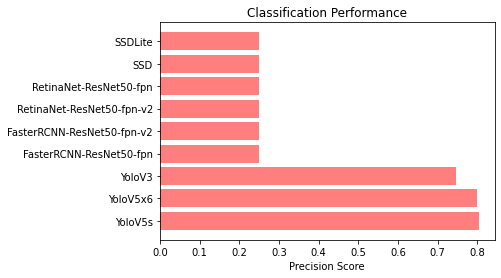

In [18]:
import matplotlib.pyplot as plt2
plt2.barh(y_pos, precision, align='center', alpha=0.5,color='red')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Precision Score')
plt2.title('Classification Performance')
plt2.show()

# Recall

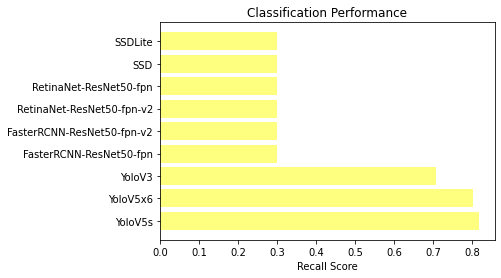

In [19]:
import matplotlib.pyplot as plt2
plt2.barh(y_pos, recall, align='center', alpha=0.5,color='yellow')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Recall Score')
plt2.title('Classification Performance')
plt2.show()

# mAP

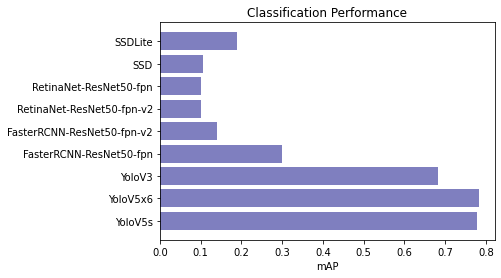

In [20]:
import matplotlib.pyplot as plt2
plt2.barh(y_pos, mAP, align='center', alpha=0.5,color='navy')
plt2.yticks(y_pos, classifier)
plt2.xlabel('mAP')
plt2.title('Classification Performance')
plt2.show()